# 🐍 Python Data Visualization — Complete Masterclass
### From Zero to Expert | Prodigy Training Hub

---

**Instructor:** Kajola Gbenga Adewale | Prodigy Training Hub  
**Level:** Beginner → Intermediate → Advanced  
**Datasets used:** Real-world Nigerian Retail Sales (CSV) & Student Performance (Excel)

---

## What You Will Learn

By the end of this notebook you will be able to:

1. Understand every major chart type in Python — what it is, why it exists, and when to use it
2. Read and visualize data from real CSV and Excel files
3. Use **Matplotlib**, **Seaborn**, and **Plotly** confidently
4. Interpret charts correctly (axes, legends, outliers, distributions, trends)
5. Build a full mini data analysis project using real datasets

---

## How to Use This Notebook

- Run every cell **in order** from top to bottom
- Read every markdown explanation **before** running the code cell below it
- If you get an error, check that you have installed the required libraries (Section 1)

---
> *"A picture is worth a thousand data points."*


---
## Section 1 — Setting Up Your Environment

### 1.1 Install Required Libraries

Before we do anything, we need to install the Python libraries we will use throughout this notebook.

| Library | What It Does |
|---------|-------------|
| **matplotlib** | The oldest and most fundamental Python plotting library. Everything is built on top of it. |
| **seaborn** | Built on top of matplotlib. Makes beautiful statistical charts with less code. |
| **plotly** | Creates interactive charts (zoom, hover, click). Great for dashboards. |
| **pandas** | Reads and manages tabular data (spreadsheets, CSV files). |
| **numpy** | Handles numbers and mathematical operations. |
| **openpyxl** | Allows pandas to read/write Excel (.xlsx) files. |


In [1]:
# Run this cell first to install everything you need
# If you are in Google Colab or Jupyter, run this once

import subprocess, sys

libraries = ["matplotlib", "seaborn", "plotly", "pandas", "numpy", "openpyxl"]

for lib in libraries:
    subprocess.check_call([sys.executable, "-m", "pip", "install", lib, "-q"])

print("All libraries installed successfully!")


All libraries installed successfully!


### 1.2 Import Everything

Now we import all the libraries into our Python session. Think of this like opening your toolbox before starting a job.


In [2]:
# --- Core data libraries ---
import pandas as pd          # Data manipulation
import numpy as np            # Numerical computing

# --- Visualization libraries ---
import matplotlib.pyplot as plt        # Base plotting
import matplotlib.patches as mpatches  # Custom legend patches
import seaborn as sns                  # Statistical visualization
import plotly.express as px            # Interactive charts (quick)
import plotly.graph_objects as go      # Interactive charts (advanced)
from plotly.subplots import make_subplots

# --- Display settings ---
import warnings
warnings.filterwarnings('ignore')

# Make matplotlib charts look clean and large
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi']     = 100
plt.rcParams['font.size']      = 12
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

# Make seaborn use a nice default theme
sns.set_theme(style="whitegrid", palette="muted")

print("All imports successful! We are ready to visualize.")


All imports successful! We are ready to visualize.


---
## Section 2 — Loading Our Real Datasets

### Why do we use real datasets?

Real datasets are messy, meaningful, and interesting. Working with real data teaches you how charts tell true stories — not just how the code works.

We will use **two datasets** throughout this notebook:

---

### Dataset A — Nigeria Retail Sales (CSV File)
- **500 transactions** recorded across 8 Nigerian states in 2023
- Columns include: State, Category, Revenue, Profit, Customer Age, Rating, Sales Channel, and more
- We will use this to explore **sales trends, comparisons, and distributions**

### Dataset B — Prodigy Training Hub Student Performance (Excel File)
- **300 student records** across 5 programmes (Data Science, Power BI, Python, etc.)
- Columns include: Quiz Score, Final Score, Attendance, Grade, Employment status, and more
- We will use this to explore **academic performance, correlations, and programme comparisons**

---


In [3]:
# ── Load Dataset A: Nigeria Retail Sales (CSV) ──────────────────────────────
df = pd.read_csv("nigeria_retail_sales.csv")

print("Dataset A — Nigeria Retail Sales")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
df.head(5)


Dataset A — Nigeria Retail Sales
Shape: 500 rows × 18 columns



,Date,Month,Quarter,Day_of_Week,State,Category,Sales_Channel,Payment_Method,Customer_Gender,Customer_Age,Unit_Price_NGN,Quantity_Sold,Discount_Percent,Revenue_NGN,Profit_Margin,Profit_NGN,Customer_Rating,Item_Returned
0,2023-11-24,November,Q4,Friday,Kaduna,Cosmetics,Physical Store,Mobile Money,Male,68,6600.0,7,0,46200.0,0.3804,17574.48,3.3,0
1,2023-02-27,February,Q1,Monday,Port Harcourt,Cosmetics,Online,POS,Female,26,28900.0,11,20,254320.0,0.2324,59103.97,5.0,0
2,2023-01-13,January,Q1,Friday,Ibadan,Electronics,Physical Store,Cash,Male,20,103900.0,10,0,1039000.0,0.2535,263386.50,2.3,0
3,2023-05-21,May,Q2,Sunday,Kaduna,Food & Beverage,Wholesale,Bank Transfer,Female,42,1700.0,9,5,14535.0,0.2930,4258.76,4.8,0
4,2023-05-06,May,Q2,Saturday,Kano,Clothing,Physical Store,Bank Transfer,Female,27,21300.0,14,5,283290.0,0.3950,111899.55,1.6,0


In [4]:
# Check column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              500 non-null    object 
 1   Month             500 non-null    object 
 2   Quarter           500 non-null    object 
 3   Day_of_Week       500 non-null    object 
 4   State             500 non-null    object 
 5   Category          500 non-null    object 
 6   Sales_Channel     500 non-null    object 
 7   Payment_Method    500 non-null    object 
 8   Customer_Gender   500 non-null    object 
 9   Customer_Age      500 non-null    int64  
 10  Unit_Price_NGN    500 non-null    float64
 11  Quantity_Sold     500 non-null    int64  
 12  Discount_Percent  500 non-null    int64  
 13  Revenue_NGN       500 non-null    float64
 14  Profit_Margin     500 non-null    float64
 15  Profit_NGN        500 non-null    float64
 16  Customer_Rating   500 non-null    float64
 1

In [5]:
# Quick summary statistics — understand what numbers look like
df.describe().round(2)


,Customer_Age,Unit_Price_NGN,Quantity_Sold,Discount_Percent,Revenue_NGN,Profit_Margin,Profit_NGN,Customer_Rating,Item_Returned
count,500.00,500.0,500.00,500.0,500.00,500.00,500.00,500.00,500.00
mean,43.85,63385.0,9.81,6.6,611400.71,0.25,160829.81,3.32,0.11
std,16.57,86178.1,5.43,6.7,1030868.38,0.10,307720.52,1.00,0.32
min,16.00,800.0,1.00,0.0,880.00,0.08,310.90,1.50,0.00
25%,30.00,7400.0,5.00,0.0,53160.00,0.17,11178.32,2.50,0.00
50%,44.00,21050.0,10.00,5.0,153075.00,0.25,33922.20,3.40,0.00
75%,58.25,93700.0,14.00,10.0,543980.00,0.34,140112.15,4.20,0.00
max,71.00,349600.0,19.00,20.0,5212800.00,0.42,2004343.44,5.00,1.00


In [6]:
# ── Load Dataset B: Student Performance (Excel) ─────────────────────────────
# We load the first sheet (Student_Records) for now
students = pd.read_excel("prodigy_student_performance.xlsx", sheet_name="Student_Records")

print("Dataset B — Student Performance (Prodigy Training Hub)")
print(f"Shape: {students.shape[0]} rows × {students.shape[1]} columns")
print()
students.head(5)


Dataset B — Student Performance (Prodigy Training Hub)
Shape: 300 rows × 16 columns



,Student_ID,Programme,Cohort,Gender,Age,Attendance_Pct,Quiz_Score,Midterm_Score,Final_Score,Project_Score,Total_Score,Grade,Completion_Status,Months_to_Complete,Employed_After,Satisfaction_Rating
0,PTH-1000,Python Programming,Cohort 4,Male,40,100.0,42.2,54.9,57.0,86.0,63.1,B,Completed,4.0,1,4
1,PTH-1001,Business Analysis,Cohort 3,Male,40,78.4,54.3,72.5,65.6,100.0,75.6,A,In Progress,NaN,1,3
2,PTH-1002,Data Science,Cohort 3,Male,43,79.7,83.7,43.9,55.7,48.1,55.3,C,Dropped Out,NaN,0,2
3,PTH-1003,Project Management,Cohort 3,Female,30,68.6,79.4,100.0,74.9,89.2,84.9,A,Dropped Out,NaN,1,5
4,PTH-1004,Data Science,Cohort 2,Female,24,94.5,82.1,60.7,91.3,73.5,78.5,A,Completed,11.0,0,3


In [7]:
# Quick summary of student data
students.describe().round(2)


,Age,Attendance_Pct,Quiz_Score,Midterm_Score,Final_Score,Project_Score,Total_Score,Months_to_Complete,Employed_After,Satisfaction_Rating
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00,238.00,300.00,300.00
mean,35.58,76.62,68.48,64.46,69.22,70.44,68.53,7.36,0.63,3.90
std,10.08,13.45,13.86,17.35,15.38,14.16,7.76,2.85,0.48,1.03
min,18.00,37.30,30.60,6.00,24.70,21.90,39.00,3.00,0.00,1.00
25%,27.00,67.75,59.08,53.10,59.15,61.58,63.20,5.00,0.00,3.00
50%,35.00,76.30,68.35,63.60,70.25,70.00,68.20,7.00,1.00,4.00
75%,43.00,86.35,79.25,75.50,80.03,80.70,73.80,10.00,1.00,5.00
max,54.00,100.00,100.00,100.00,100.00,100.00,90.80,12.00,1.00,5.00


---
## Section 3 — The Three Visualization Libraries Explained

Before we draw any chart, let's understand the three tools we will use.

---

### 3.1 Matplotlib — The Foundation

Matplotlib is the **grandfather** of Python visualization. Every other library is built on top of it.

**How it works:** You create a **figure** (the whole canvas) and one or more **axes** (the actual chart area). Then you add things to the axes.

```
Figure
└── Axes (chart 1)
    ├── Title
    ├── X-axis label
    ├── Y-axis label
    └── Plot elements (lines, bars, points...)
└── Axes (chart 2)  ← you can have multiple charts in one figure
```

**When to use Matplotlib:**
- When you need full control over every detail
- When building custom or complex layouts
- As a base when other libraries don't have what you need

---

### 3.2 Seaborn — Statistics Made Beautiful

Seaborn is built on top of matplotlib but makes **statistical charts much easier**. It works directly with pandas DataFrames.

**When to use Seaborn:**
- When you need box plots, violin plots, heatmaps, pair plots
- When you want beautiful charts with minimal code
- For **exploratory data analysis (EDA)**

---

### 3.3 Plotly — Interactive Charts

Plotly charts are **interactive** — you can zoom, hover over data points, and click on legend items to hide/show series.

**When to use Plotly:**
- When presenting to stakeholders or clients
- When building dashboards
- When your audience needs to explore the data themselves

---


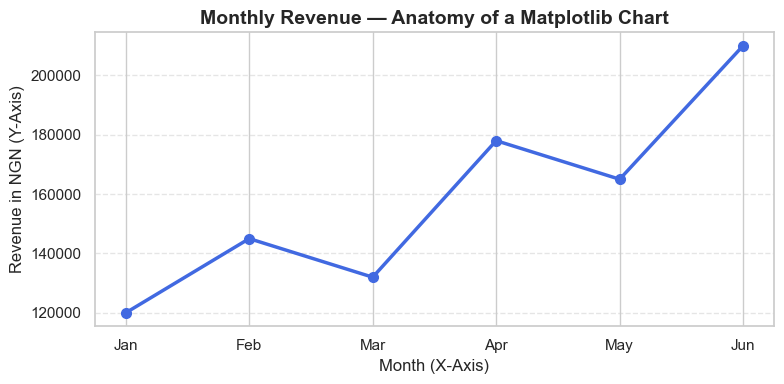

This is the basic structure of every matplotlib chart.
fig = the entire canvas | ax = the chart area inside the canvas


In [8]:
# ── MATPLOTLIB: Basic Anatomy of a Chart ────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))  # Create figure and axes

# Sample data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
sales  = [120000, 145000, 132000, 178000, 165000, 210000]

ax.plot(months, sales, color='royalblue', linewidth=2.5, marker='o', markersize=7)

# Anatomy labels
ax.set_title("Monthly Revenue — Anatomy of a Matplotlib Chart", fontsize=14, fontweight='bold')
ax.set_xlabel("Month (X-Axis)", fontsize=12)
ax.set_ylabel("Revenue in NGN (Y-Axis)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("This is the basic structure of every matplotlib chart.")
print("fig = the entire canvas | ax = the chart area inside the canvas")


---
## Section 4 — Every Chart Type in Python: Definitions, Uses & Examples

We will now go through **every major chart type** one by one.

For each chart you will see:
- **What it is** — a plain-English definition
- **Why it exists** — the problem it solves
- **When to use it** — the right situations
- **When NOT to use it** — common mistakes
- **Code examples** — using our real datasets
- **How to read/interpret it** — what to look for

---


### 4.1 Line Chart

#### What is it?
A **line chart** connects data points with a continuous line. The X-axis is usually time (dates, months, years), and the Y-axis shows a measured value.

#### Why does it exist?
Humans are naturally good at detecting trends and patterns in lines. A line chart instantly answers: *"Is this going up or down over time?"*

#### When to USE it:
- Tracking values **over time** (sales per month, temperature per day, stock prices)
- Showing **trends and momentum**
- Comparing trends of **multiple categories** (multiple lines)

#### When NOT to use it:
- When X-axis values have no natural order (e.g., categories like "Lagos", "Kano" — use a Bar chart instead)
- When you have only 1 or 2 data points

#### How to interpret it:
- **Rising line** = the value is increasing over time
- **Falling line** = the value is decreasing
- **Flat line** = the value is stable
- **Steep slope** = fast change; **gentle slope** = slow change
- Where lines **cross** = a reversal point (one thing surpassed another)


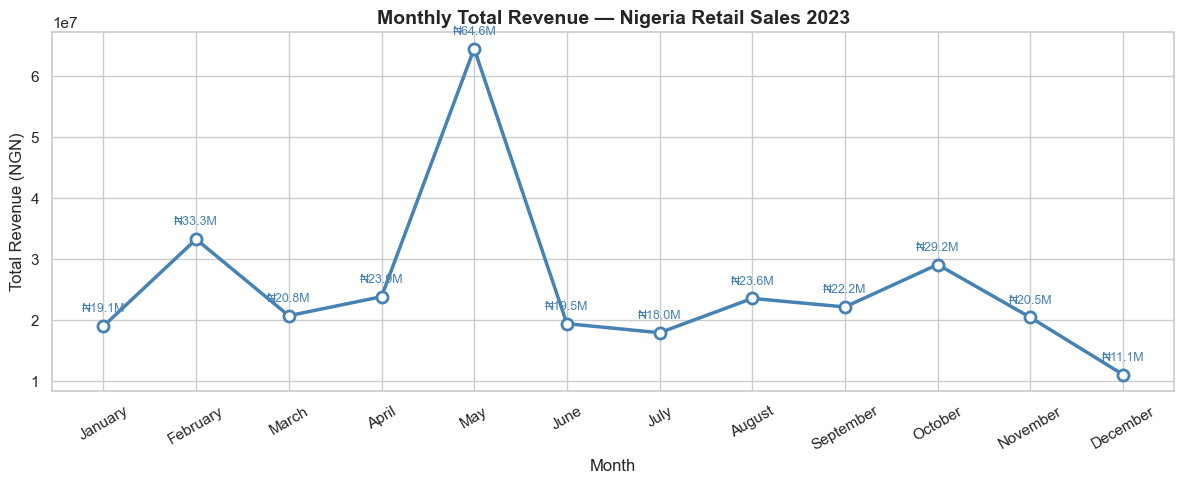

Insight: Look for which months had the highest and lowest revenue.


In [9]:
# ── LINE CHART Example 1: Monthly Total Revenue from our CSV dataset ─────────

# Step 1: Prepare data — group by Month and sum Revenue
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_rev = (df.groupby('Month')['Revenue_NGN']
                 .sum()
                 .reindex(month_order)
                 .dropna()
                 .reset_index())

# Step 2: Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_rev['Month'], monthly_rev['Revenue_NGN'],
        color='steelblue', linewidth=2.5, marker='o', markersize=8,
        markerfacecolor='white', markeredgewidth=2)

# Add value labels on each point
for i, row in monthly_rev.iterrows():
    ax.annotate(f"₦{row['Revenue_NGN']/1e6:.1f}M",
                xy=(row['Month'], row['Revenue_NGN']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='steelblue')

ax.set_title("Monthly Total Revenue — Nigeria Retail Sales 2023", fontsize=14, fontweight='bold')
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Revenue (NGN)", fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
print("Insight: Look for which months had the highest and lowest revenue.")


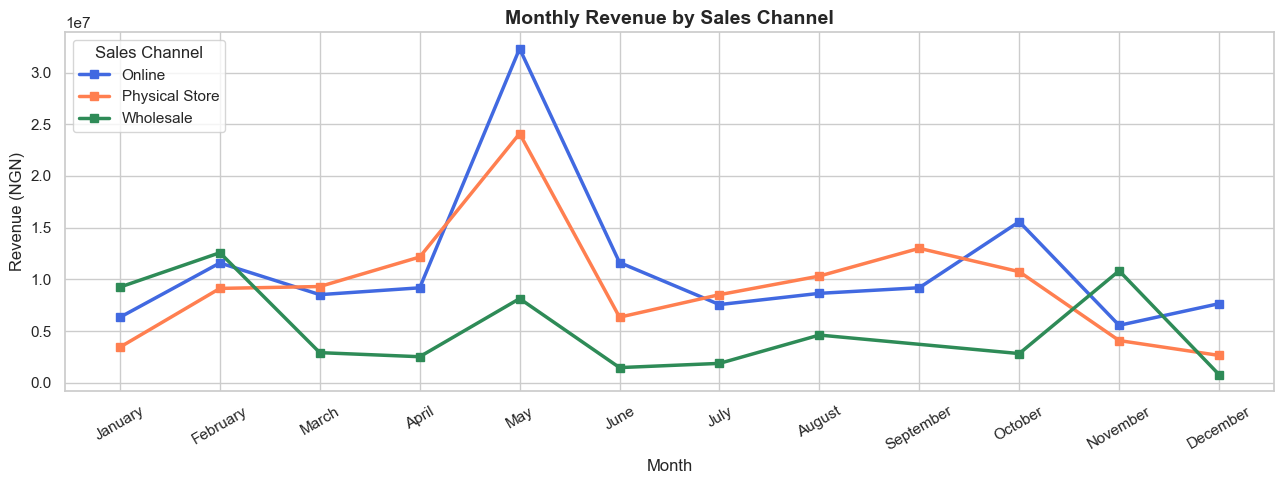

Interpretation: Where the lines are close = channels performing similarly.
Where one line pulls away = that channel is dominating that month.


In [10]:
# ── LINE CHART Example 2: Multiple lines — Revenue by Sales Channel over time ─

channel_month = (df.groupby(['Month', 'Sales_Channel'])['Revenue_NGN']
                   .sum()
                   .reset_index())
channel_month['Month'] = pd.Categorical(channel_month['Month'], categories=month_order, ordered=True)
channel_month = channel_month.sort_values('Month')

fig, ax = plt.subplots(figsize=(13, 5))
colors = {'Online': 'royalblue', 'Physical Store': 'coral', 'Wholesale': 'seagreen'}

for channel, grp in channel_month.groupby('Sales_Channel'):
    ax.plot(grp['Month'], grp['Revenue_NGN'],
            label=channel, color=colors[channel],
            linewidth=2.5, marker='s', markersize=6)

ax.set_title("Monthly Revenue by Sales Channel", fontsize=14, fontweight='bold')
ax.set_xlabel("Month"); ax.set_ylabel("Revenue (NGN)")
ax.legend(title="Sales Channel", loc='upper left')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
print("Interpretation: Where the lines are close = channels performing similarly.")
print("Where one line pulls away = that channel is dominating that month.")


---
### 4.2 Bar Chart (Vertical & Horizontal)

#### What is it?
A **bar chart** uses rectangular bars to represent the value of each category. The **height** (vertical) or **length** (horizontal) of the bar = the value.

#### Why does it exist?
It is the clearest way to **compare values across categories**. Our eyes are excellent at judging bar heights side by side.

#### When to USE it:
- Comparing values across **categories** (e.g., revenue per state, students per programme)
- Showing **rankings** (which state sold the most?)
- When categories are **discrete** (not continuous)

#### When NOT to use it:
- When you have too many categories (more than ~15 bars becomes crowded — use horizontal bars or a table)
- When you want to show change **over time** (use a Line chart instead)

#### Horizontal vs Vertical:
- **Vertical bars** — best when category labels are short
- **Horizontal bars** — best when category labels are long (state names, product names)

#### How to interpret it:
- **Taller/longer bar** = higher value
- **Compare bar heights directly** — the tallest bar is the category with the maximum value


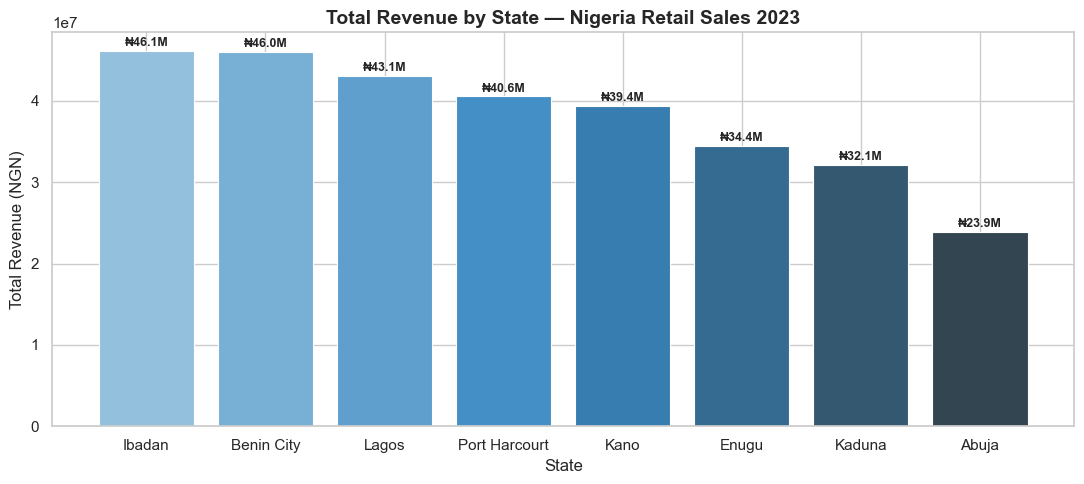

Which state generated the most revenue? The tallest bar answers that instantly.


In [11]:
# ── BAR CHART Example 1: Total Revenue by State (Vertical) ──────────────────

state_rev = df.groupby('State')['Revenue_NGN'].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(state_rev['State'], state_rev['Revenue_NGN'],
              color=sns.color_palette("Blues_d", len(state_rev)),
              edgecolor='white', linewidth=0.8)

# Add value labels on top of bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 200000,
            f'₦{h/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Total Revenue by State — Nigeria Retail Sales 2023", fontsize=14, fontweight='bold')
ax.set_xlabel("State"); ax.set_ylabel("Total Revenue (NGN)")
plt.tight_layout()
plt.show()
print("Which state generated the most revenue? The tallest bar answers that instantly.")


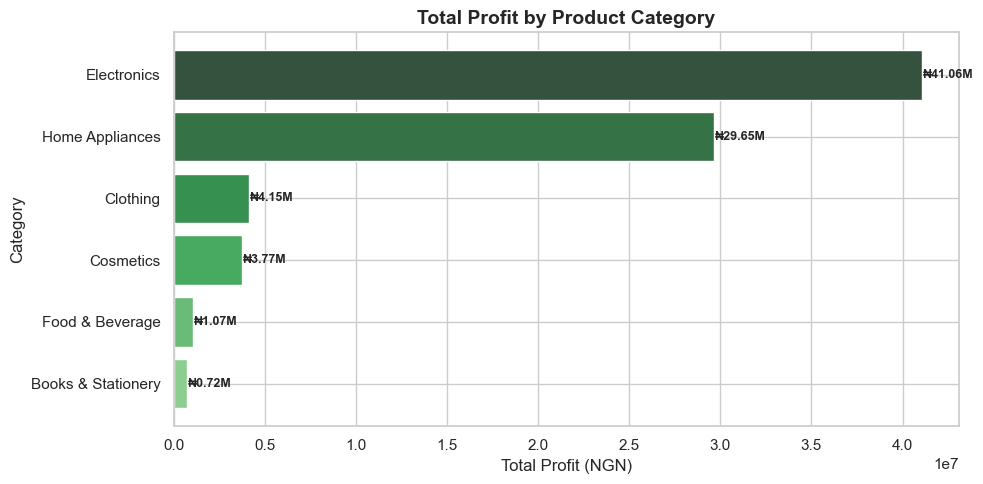

In [12]:
# ── BAR CHART Example 2: Horizontal bar — Total Profit by Product Category ────

cat_profit = df.groupby('Category')['Profit_NGN'].sum().sort_values().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_profit['Category'], cat_profit['Profit_NGN'],
               color=sns.color_palette("Greens_d", len(cat_profit)),
               edgecolor='white')

for bar in bars:
    w = bar.get_width()
    ax.text(w + 50000, bar.get_y() + bar.get_height()/2,
            f'₦{w/1e6:.2f}M', va='center', fontsize=9, fontweight='bold')

ax.set_title("Total Profit by Product Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Total Profit (NGN)"); ax.set_ylabel("Category")
plt.tight_layout()
plt.show()


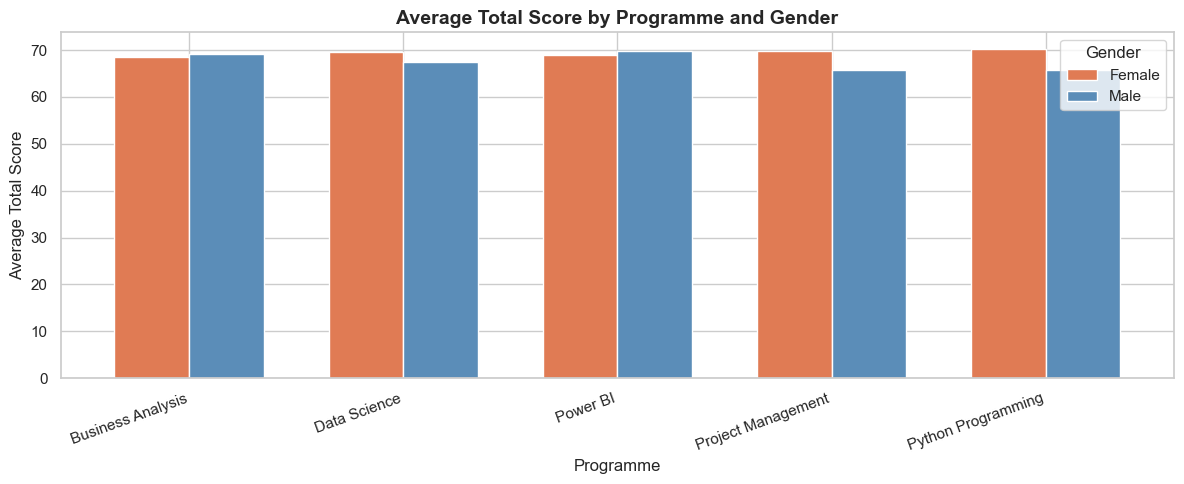

Grouped bars let you compare two things at once: programme AND gender.


In [13]:
# ── BAR CHART Example 3: Grouped bar — Average Score by Programme & Gender ────

prog_gender = students.groupby(['Programme','Gender'])['Total_Score'].mean().unstack()

prog_gender.plot(kind='bar', figsize=(12, 5),
                 color=['#E07B54','#5B8DB8'], edgecolor='white',
                 width=0.7)

plt.title("Average Total Score by Programme and Gender", fontsize=14, fontweight='bold')
plt.xlabel("Programme"); plt.ylabel("Average Total Score")
plt.xticks(rotation=20, ha='right')
plt.legend(title="Gender")
plt.tight_layout()
plt.show()
print("Grouped bars let you compare two things at once: programme AND gender.")


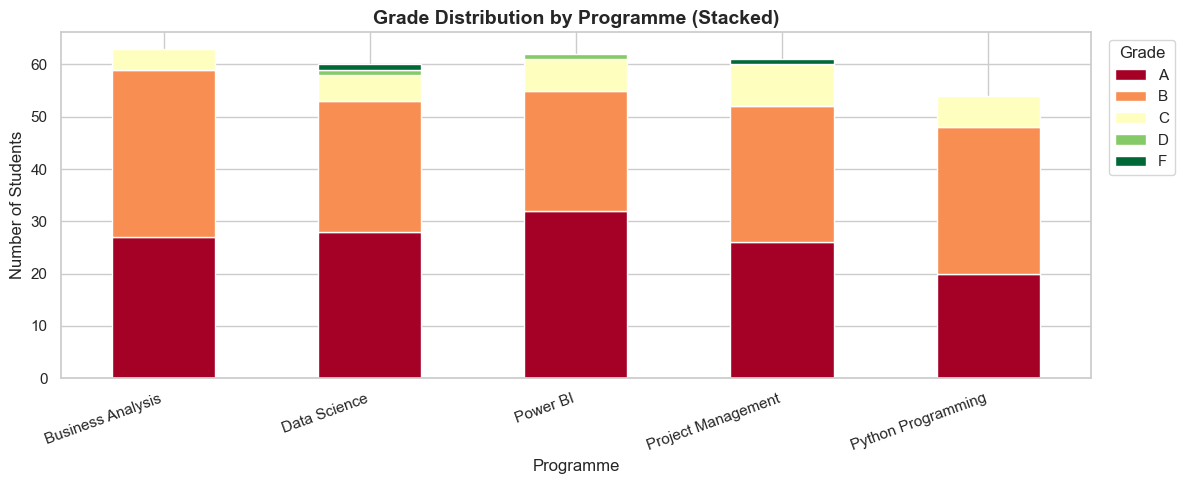

Stacked bars show COMPOSITION — what fraction of each programme got each grade.


In [14]:
# ── BAR CHART Example 4: Stacked bar — Grade distribution per Programme ────────

grade_prog = students.groupby(['Programme','Grade']).size().unstack(fill_value=0)
grade_prog = grade_prog[['A','B','C','D','F']]  # order grades

grade_prog.plot(kind='bar', stacked=True, figsize=(12, 5),
                colormap='RdYlGn', edgecolor='white')

plt.title("Grade Distribution by Programme (Stacked)", fontsize=14, fontweight='bold')
plt.xlabel("Programme"); plt.ylabel("Number of Students")
plt.xticks(rotation=20, ha='right')
plt.legend(title="Grade", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()
print("Stacked bars show COMPOSITION — what fraction of each programme got each grade.")


---
### 4.3 Histogram

#### What is it?
A **histogram** shows the **distribution of a single numerical variable**. It divides the data into ranges called **bins** and counts how many data points fall into each bin.

#### The key difference from a bar chart:
- **Bar chart** → compares separate, distinct categories (State A vs State B)
- **Histogram** → shows how a continuous number is spread out (e.g., how many customers are aged 20-25, 25-30, 30-35...)

#### Why does it exist?
To answer: *"What does this number look like across all records? Is it evenly spread? Skewed? Concentrated in one area?"*

#### When to USE it:
- Understanding the **shape of a distribution** (normal, skewed, bimodal)
- Checking if data is **evenly spread or concentrated**
- Exploring **age, income, scores, prices**

#### How to interpret it:
- **Tall bin** = many data points fall in that range (common values)
- **Short bin** = few data points (rare values)
- **Bell shape (normal)** = most values cluster in the middle
- **Right-skewed** = most values are low, but a few are very high (like income)
- **Left-skewed** = most values are high, but a few are very low
- **Bimodal (two humps)** = two distinct groups exist in the data


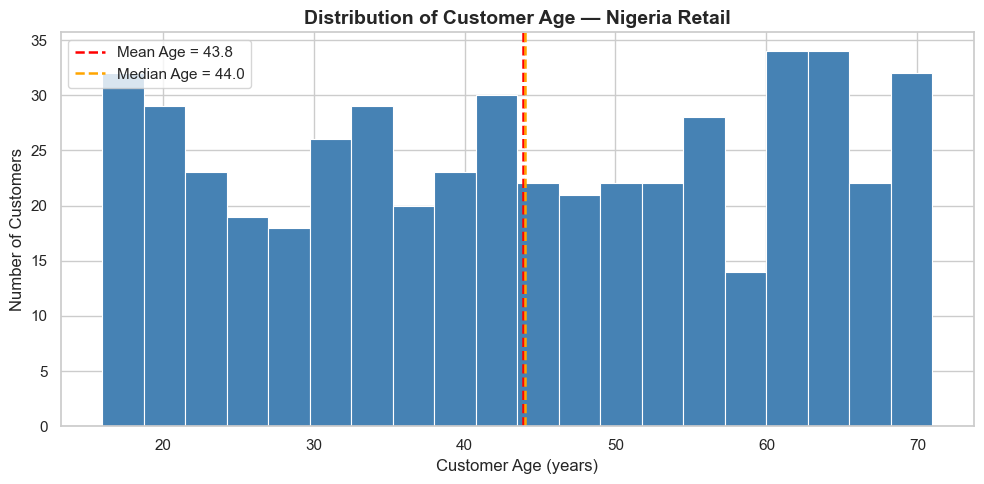

Mean:   43.85
Median: 44.00
Std:    16.57

Interpretation: If mean ≈ median, the distribution is roughly symmetric.
If mean > median, it is right-skewed (pulled by high values).


In [15]:
# ── HISTOGRAM Example 1: Distribution of Customer Age ────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Customer_Age'], bins=20, color='steelblue', edgecolor='white', linewidth=0.8)

ax.axvline(df['Customer_Age'].mean(), color='red', linestyle='--', linewidth=1.8,
           label=f"Mean Age = {df['Customer_Age'].mean():.1f}")
ax.axvline(df['Customer_Age'].median(), color='orange', linestyle='--', linewidth=1.8,
           label=f"Median Age = {df['Customer_Age'].median():.1f}")

ax.set_title("Distribution of Customer Age — Nigeria Retail", fontsize=14, fontweight='bold')
ax.set_xlabel("Customer Age (years)"); ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean:   {df['Customer_Age'].mean():.2f}")
print(f"Median: {df['Customer_Age'].median():.2f}")
print(f"Std:    {df['Customer_Age'].std():.2f}")
print()
print("Interpretation: If mean ≈ median, the distribution is roughly symmetric.")
print("If mean > median, it is right-skewed (pulled by high values).")


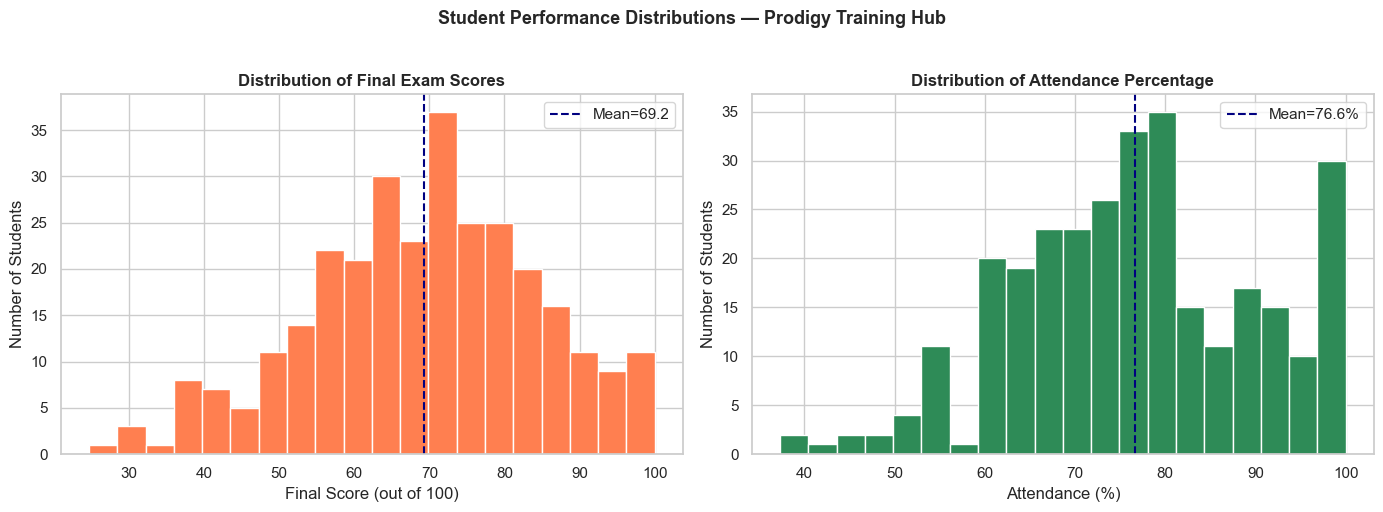

In [16]:
# ── HISTOGRAM Example 2: Distribution of Final Exam Scores (Students) ─────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(students['Final_Score'], bins=20, color='coral', edgecolor='white')
axes[0].set_title("Distribution of Final Exam Scores", fontweight='bold')
axes[0].set_xlabel("Final Score (out of 100)")
axes[0].set_ylabel("Number of Students")
axes[0].axvline(students['Final_Score'].mean(), color='navy', linestyle='--',
                label=f"Mean={students['Final_Score'].mean():.1f}")
axes[0].legend()

axes[1].hist(students['Attendance_Pct'], bins=20, color='seagreen', edgecolor='white')
axes[1].set_title("Distribution of Attendance Percentage", fontweight='bold')
axes[1].set_xlabel("Attendance (%)")
axes[1].set_ylabel("Number of Students")
axes[1].axvline(students['Attendance_Pct'].mean(), color='navy', linestyle='--',
                label=f"Mean={students['Attendance_Pct'].mean():.1f}%")
axes[1].legend()

plt.suptitle("Student Performance Distributions — Prodigy Training Hub", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
### 4.4 Box Plot (Box-and-Whisker Plot)

#### What is it?
A **box plot** is a compact visual summary of a distribution using 5 key statistics:

```
          ┌─────────────┐
  ├───────┤   IQR Box   ├───────┤  ●  (outlier)
          └─────────────┘
  Min    Q1   Median   Q3    Max
(whisker)            (whisker)
```

| Part | Meaning |
|------|---------|
| **Median line (middle of box)** | The middle value — 50% of data is below, 50% above |
| **Box bottom (Q1)** | 25th percentile — 25% of data is below this |
| **Box top (Q3)** | 75th percentile — 75% of data is below this |
| **Box height (IQR)** | Interquartile Range = Q3 − Q1 — the middle 50% of data lives here |
| **Whiskers** | Extend to the smallest/largest values that are NOT outliers |
| **Dots beyond whiskers** | **Outliers** — unusually high or low values |

#### Why does it exist?
Box plots pack the entire shape of a distribution into a tiny space and make it easy to **compare distributions across multiple groups** side by side.

#### When to USE it:
- Comparing distributions across **groups** (e.g., scores by programme, revenue by state)
- **Spotting outliers** quickly
- Understanding **spread and skewness** at a glance

#### How to interpret it:
- **Tall box** = data is widely spread (high variance)
- **Short box** = data is tightly packed (low variance)
- **Median near bottom of box** = right-skewed distribution
- **Median near top of box** = left-skewed
- **Many dots** = many outliers in the data


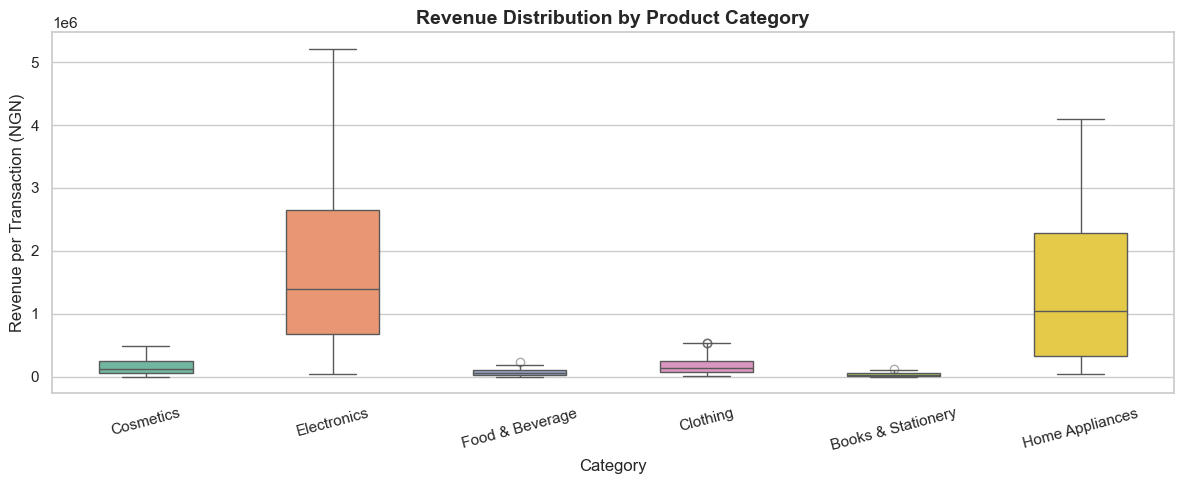

Reading this chart:
- The RED DOTS are outliers (transactions that were unusually large or small)
- The LINE inside the box = median revenue for that category
- A TALL box = revenues vary a lot within that category
- A SHORT box = revenues are more consistent


In [17]:
# ── BOX PLOT Example 1: Revenue distribution by Product Category ─────────────

fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(data=df, x='Category', y='Revenue_NGN', ax=ax,
            palette='Set2', width=0.5, flierprops=dict(marker='o', color='red', alpha=0.5))

ax.set_title("Revenue Distribution by Product Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Category"); ax.set_ylabel("Revenue per Transaction (NGN)")
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print("Reading this chart:")
print("- The RED DOTS are outliers (transactions that were unusually large or small)")
print("- The LINE inside the box = median revenue for that category")
print("- A TALL box = revenues vary a lot within that category")
print("- A SHORT box = revenues are more consistent")


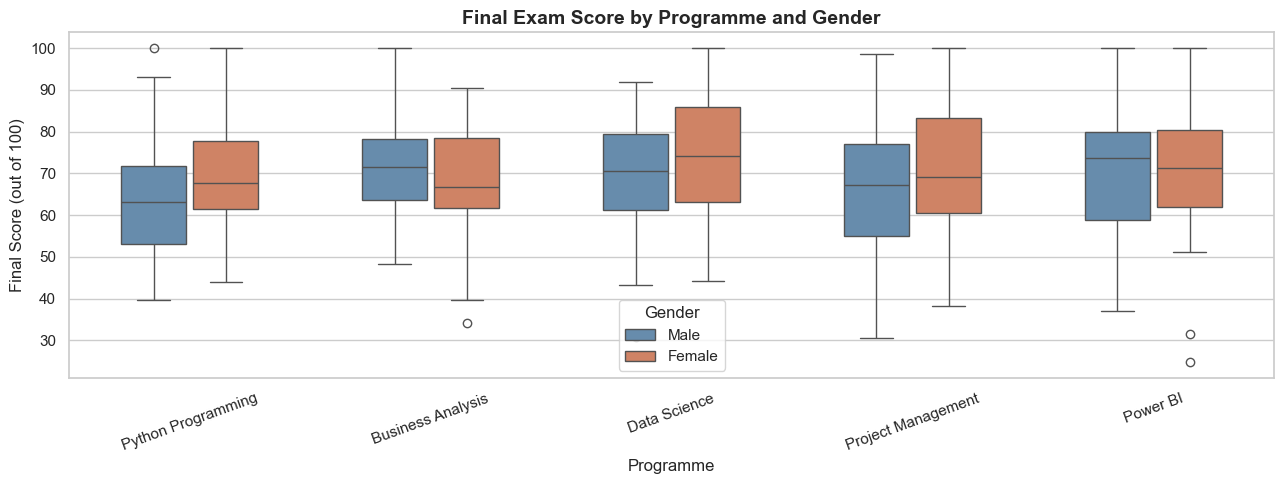

With hue='Gender', each programme shows TWO boxes — one per gender.
This helps you instantly see if one gender consistently scores higher.


In [18]:
# ── BOX PLOT Example 2: Final Score by Programme with gender split (hue) ─────

fig, ax = plt.subplots(figsize=(13, 5))

sns.boxplot(data=students, x='Programme', y='Final_Score', hue='Gender',
            palette={'Male':'#5B8DB8','Female':'#E07B54'},
            ax=ax, width=0.6, gap=0.1)

ax.set_title("Final Exam Score by Programme and Gender", fontsize=14, fontweight='bold')
ax.set_xlabel("Programme"); ax.set_ylabel("Final Score (out of 100)")
ax.tick_params(axis='x', rotation=20)
ax.legend(title="Gender")
plt.tight_layout()
plt.show()
print("With hue='Gender', each programme shows TWO boxes — one per gender.")
print("This helps you instantly see if one gender consistently scores higher.")


═══ 5-Number Summary for Electronics Revenue ═══
  Minimum (excl. outliers):  ₦41,580
  Q1  (25th percentile):     ₦675,700
  Median (50th percentile):  ₦1,393,560
  Q3  (75th percentile):     ₦2,645,250
  Maximum (excl. outliers):  ₦5,212,800
  IQR (Q3 - Q1):             ₦1,969,550
  Outlier threshold (upper): ₦5,599,575
  Outlier count:             0 transactions


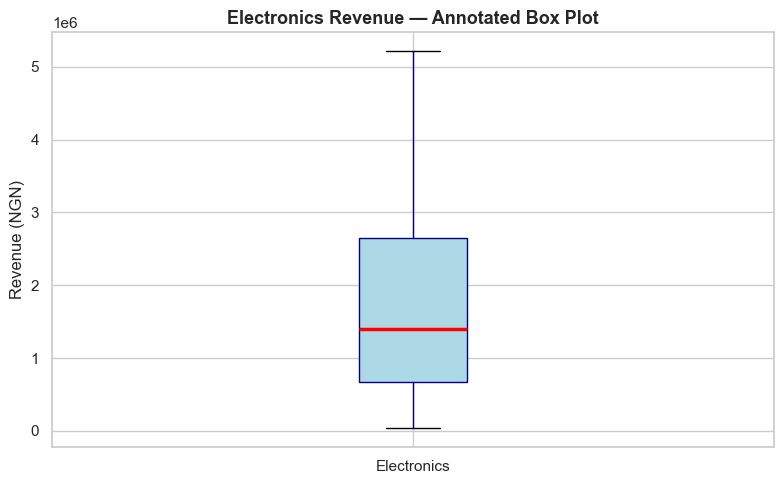

In [19]:
# ── BOX PLOT Example 3: Annotating the 5-number summary ─────────────────────

data_sample = df[df['Category'] == 'Electronics']['Revenue_NGN']

q1  = data_sample.quantile(0.25)
med = data_sample.median()
q3  = data_sample.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data_sample, vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2.5),
           whiskerprops=dict(color='navy'),
           flierprops=dict(marker='o', color='orange', markersize=6))

ax.set_title("Electronics Revenue — Annotated Box Plot", fontsize=13, fontweight='bold')
ax.set_ylabel("Revenue (NGN)")
ax.set_xticklabels(['Electronics'])

print("═══ 5-Number Summary for Electronics Revenue ═══")
print(f"  Minimum (excl. outliers):  ₦{data_sample[data_sample >= lower_fence].min():,.0f}")
print(f"  Q1  (25th percentile):     ₦{q1:,.0f}")
print(f"  Median (50th percentile):  ₦{med:,.0f}")
print(f"  Q3  (75th percentile):     ₦{q3:,.0f}")
print(f"  Maximum (excl. outliers):  ₦{data_sample[data_sample <= upper_fence].max():,.0f}")
print(f"  IQR (Q3 - Q1):             ₦{iqr:,.0f}")
print(f"  Outlier threshold (upper): ₦{upper_fence:,.0f}")
print(f"  Outlier count:             {(data_sample > upper_fence).sum()} transactions")
plt.tight_layout()
plt.show()


---
### 4.5 Violin Plot

#### What is it?
A **violin plot** is like a box plot but enhanced. It shows the **full shape** of the distribution (using a technique called kernel density estimation) on both sides of a central axis. The **fatter** the violin at a certain value, the **more data points** exist there.

#### Violin vs Box Plot:
| Feature | Box Plot | Violin Plot |
|---------|----------|-------------|
| Shows 5-number summary | Yes | Sometimes (with inner box) |
| Shows full distribution shape | No | **Yes** |
| Detects bimodal distributions | No | **Yes** |
| Compact | Very compact | Larger |

#### When to USE it:
- When you want to see if a distribution is **bimodal** (two humps — two groups in one)
- When comparing distributions across groups AND you care about the **shape**
- Exploratory data analysis

#### How to interpret it:
- **Wide part** = more data at that value
- **Narrow part** = few data at that value
- **Two bulges (bimodal)** = two distinct subgroups in your data


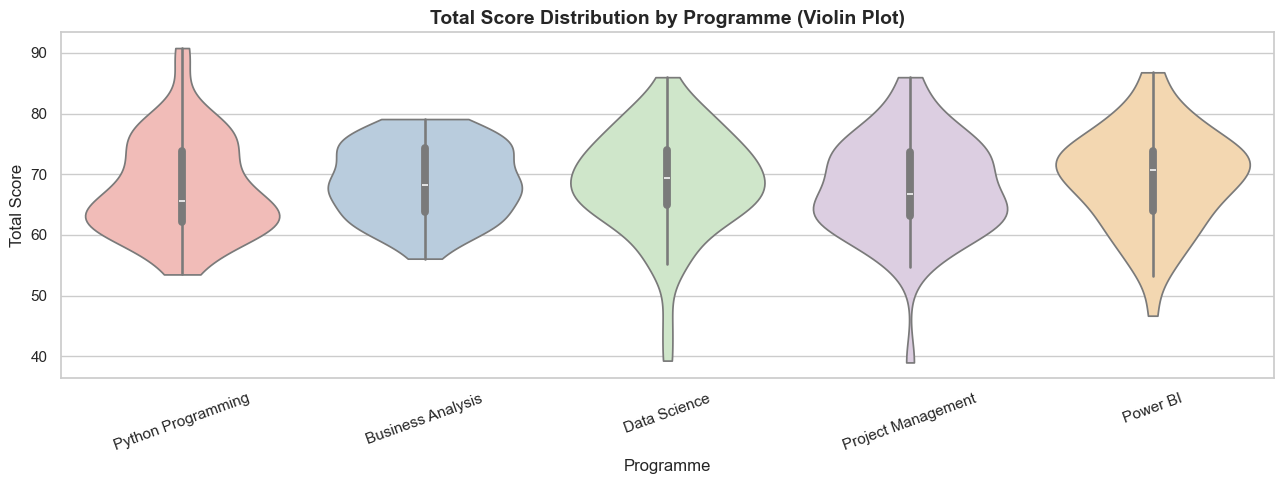

The inner box inside each violin shows the median and IQR (like a box plot).
The wider the violin at a score level, the more students scored there.


In [20]:
# ── VIOLIN PLOT Example 1: Score distribution by Programme ───────────────────

fig, ax = plt.subplots(figsize=(13, 5))

sns.violinplot(data=students, x='Programme', y='Total_Score',
               palette='Pastel1', inner='box', ax=ax, cut=0)

ax.set_title("Total Score Distribution by Programme (Violin Plot)", fontsize=14, fontweight='bold')
ax.set_xlabel("Programme"); ax.set_ylabel("Total Score")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
print("The inner box inside each violin shows the median and IQR (like a box plot).")
print("The wider the violin at a score level, the more students scored there.")


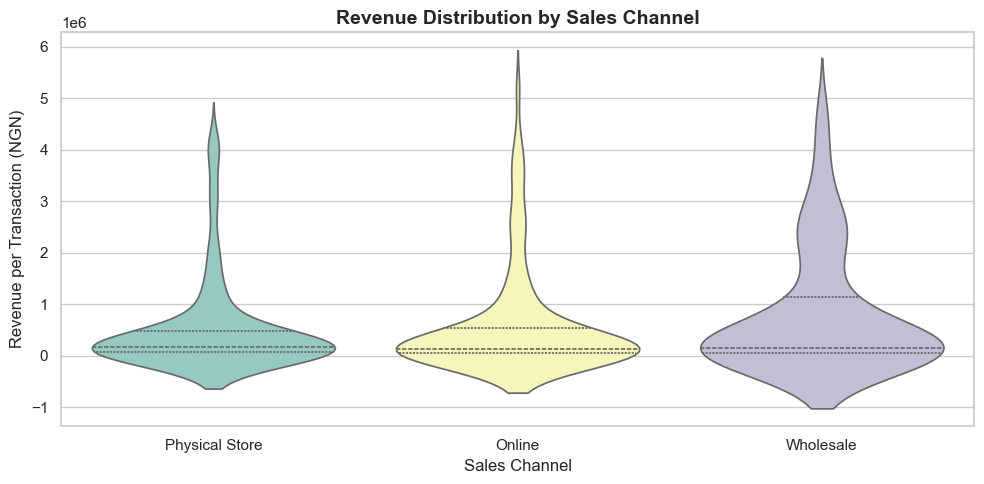

inner='quartile' shows three lines inside the violin: Q1, Median, Q3.


In [21]:
# ── VIOLIN PLOT Example 2: Revenue by Sales Channel ──────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(data=df, x='Sales_Channel', y='Revenue_NGN',
               palette='Set3', inner='quartile', ax=ax)

ax.set_title("Revenue Distribution by Sales Channel", fontsize=14, fontweight='bold')
ax.set_xlabel("Sales Channel"); ax.set_ylabel("Revenue per Transaction (NGN)")
plt.tight_layout()
plt.show()
print("inner='quartile' shows three lines inside the violin: Q1, Median, Q3.")


---
### 4.6 Scatter Plot

#### What is it?
A **scatter plot** places each data point as a **dot** on a 2D grid. The position of the dot on the X-axis shows one variable; the position on the Y-axis shows another.

#### Why does it exist?
To reveal **relationships (correlations) between two numerical variables**.

#### The four relationships you can see:
1. **Positive correlation** — as X increases, Y increases (dots go up-right)
2. **Negative correlation** — as X increases, Y decreases (dots go down-right)
3. **No correlation** — dots scattered randomly, no pattern
4. **Non-linear relationship** — a curve pattern (not a straight line)

#### When to USE it:
- Exploring relationships between two numerical columns
- Detecting **clusters** of similar data points
- Identifying **outliers** (isolated dots far from the main group)

#### When NOT to use it:
- When you have millions of data points (the plot becomes a blob — use a heatmap instead)
- When comparing categories (use bar chart)


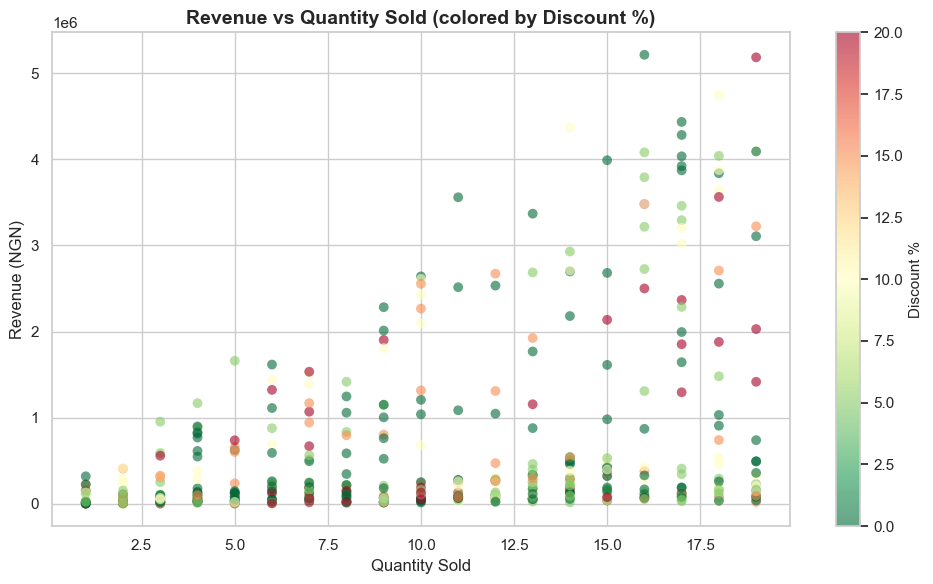

Color encodes a third variable (discount %). Green = low discount, Red = high discount.
Look: do high-discount transactions also tend to have lower revenue?


In [22]:
# ── SCATTER PLOT Example 1: Revenue vs Quantity Sold ─────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df['Quantity_Sold'], df['Revenue_NGN'],
                     c=df['Discount_Percent'], cmap='RdYlGn_r',
                     alpha=0.6, s=50, edgecolors='none')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Discount %", fontsize=11)

ax.set_title("Revenue vs Quantity Sold (colored by Discount %)", fontsize=14, fontweight='bold')
ax.set_xlabel("Quantity Sold"); ax.set_ylabel("Revenue (NGN)")
plt.tight_layout()
plt.show()
print("Color encodes a third variable (discount %). Green = low discount, Red = high discount.")
print("Look: do high-discount transactions also tend to have lower revenue?")


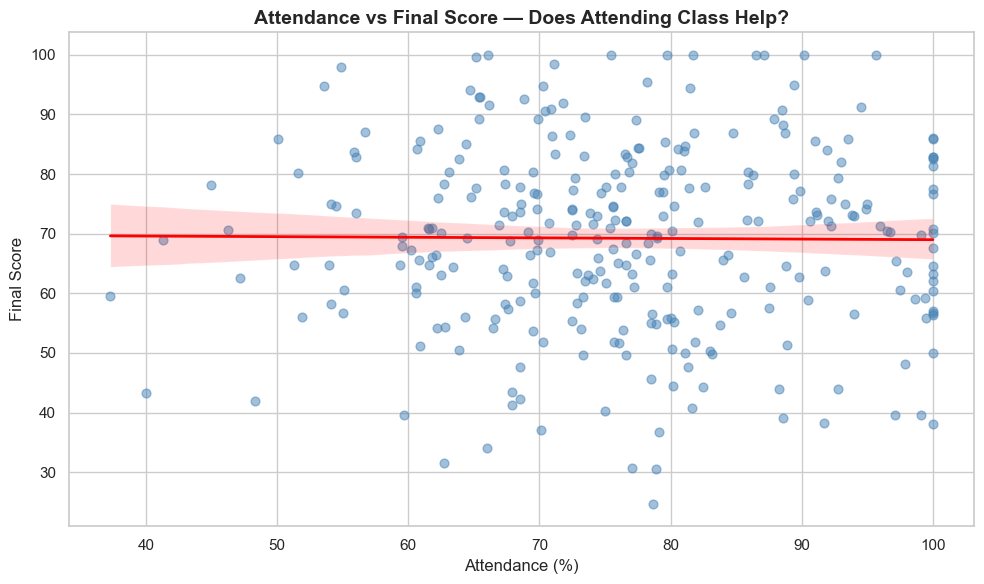

Pearson Correlation = -0.0089

Interpretation of correlation (r):
  r close to +1.0 = strong positive relationship
  r close to  0.0 = no relationship
  r close to -1.0 = strong negative relationship


In [23]:
# ── SCATTER PLOT Example 2: Attendance vs Final Score (with regression line) ──

fig, ax = plt.subplots(figsize=(10, 6))

# Seaborn's regplot adds a regression line + confidence band automatically
sns.regplot(data=students, x='Attendance_Pct', y='Final_Score',
            ax=ax, scatter_kws={'alpha':0.5, 'color':'steelblue', 's':40},
            line_kws={'color':'red', 'linewidth':2})

ax.set_title("Attendance vs Final Score — Does Attending Class Help?", fontsize=14, fontweight='bold')
ax.set_xlabel("Attendance (%)"); ax.set_ylabel("Final Score")
plt.tight_layout()
plt.show()

corr = students['Attendance_Pct'].corr(students['Final_Score'])
print(f"Pearson Correlation = {corr:.4f}")
print()
print("Interpretation of correlation (r):")
print("  r close to +1.0 = strong positive relationship")
print("  r close to  0.0 = no relationship")
print("  r close to -1.0 = strong negative relationship")


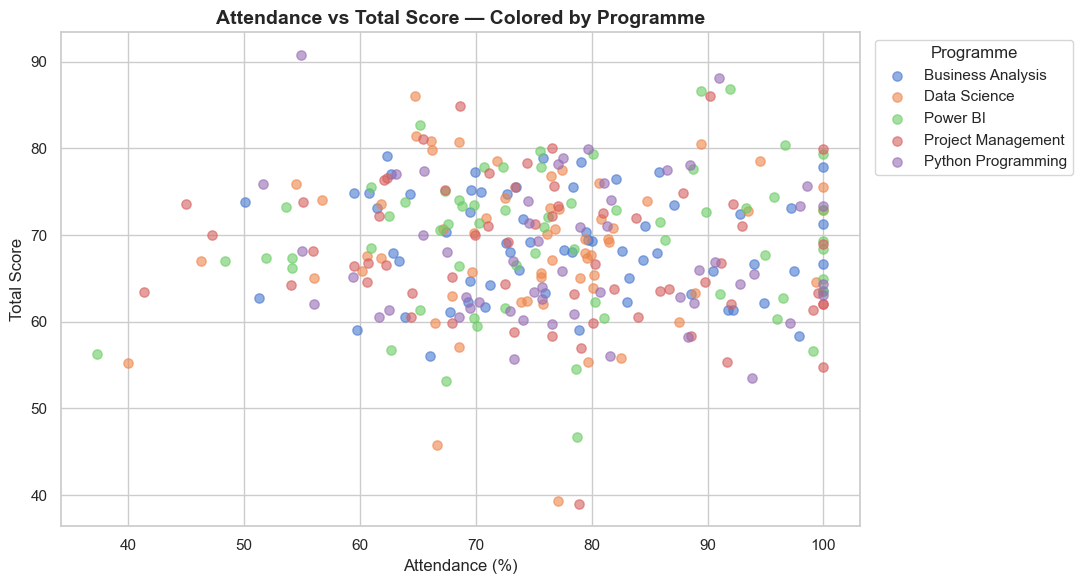

In [24]:
# ── SCATTER PLOT Example 3: Scatter with category coloring ──────────────────

fig, ax = plt.subplots(figsize=(11, 6))

for prog, grp in students.groupby('Programme'):
    ax.scatter(grp['Attendance_Pct'], grp['Total_Score'],
               label=prog, alpha=0.6, s=45)

ax.set_title("Attendance vs Total Score — Colored by Programme", fontsize=14, fontweight='bold')
ax.set_xlabel("Attendance (%)"); ax.set_ylabel("Total Score")
ax.legend(title="Programme", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()


---
### 4.7 Pie Chart & Donut Chart

#### What is it?
A **pie chart** shows how a whole is divided into parts. Each slice represents a category's **proportion** of the total (expressed as a percentage).

A **donut chart** is a pie chart with the center cut out — it looks cleaner and you can put a label in the middle.

#### When to USE it:
- Showing **proportions** (what percentage of total sales came from each channel?)
- When you have **5 or fewer categories** (more than 5 slices becomes hard to read)
- When the audience cares about **"what fraction"** more than exact numbers

#### When NOT to use it:
- When you have **many categories** (use a bar chart — humans are bad at judging angles)
- When values are **similar** (hard to see which slice is bigger — use horizontal bar)
- When showing **change over time** (use line chart)

#### How to interpret it:
- **Larger slice** = larger proportion of the total
- Always check the percentage labels — your eyes can fool you on similar-sized slices


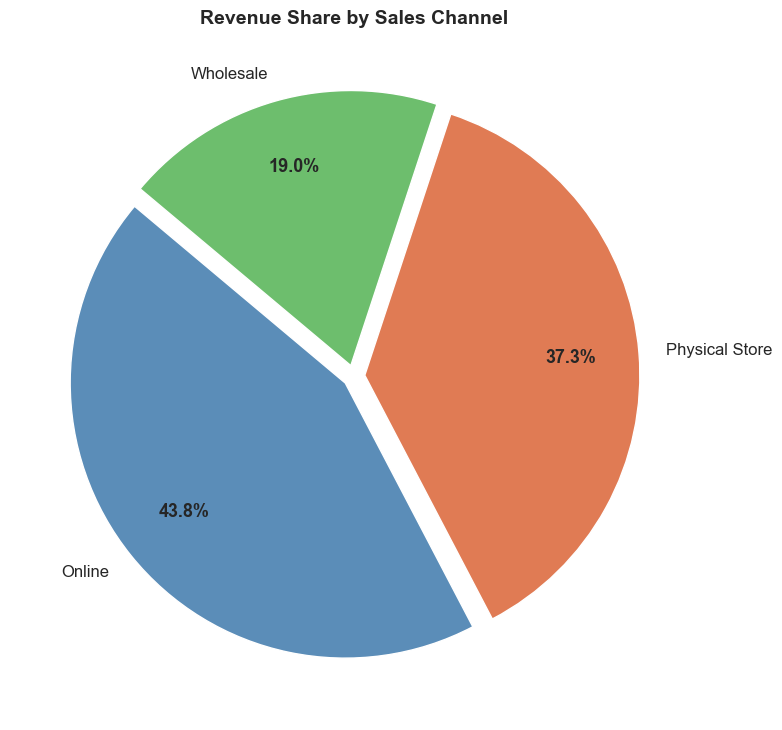

In [25]:
# ── PIE CHART Example 1: Revenue share by Sales Channel ─────────────────────

channel_rev = df.groupby('Sales_Channel')['Revenue_NGN'].sum()

colors = ['#5B8DB8', '#E07B54', '#6DBE6D']
explode = [0.04] * len(channel_rev)  # slightly separate each slice

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    channel_rev,
    labels=channel_rev.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    pctdistance=0.75,
    textprops={'fontsize': 12}
)
for t in autotexts:
    t.set_fontweight('bold')
    t.set_fontsize(13)

ax.set_title("Revenue Share by Sales Channel", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


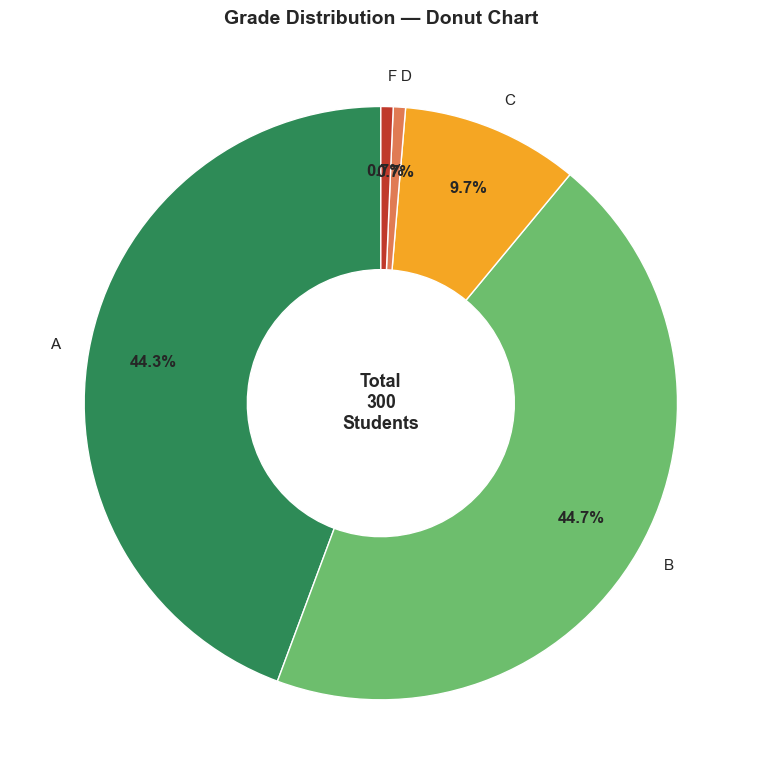

In [26]:
# ── DONUT CHART Example: Grade distribution at Prodigy Training Hub ──────────

grade_counts = students['Grade'].value_counts().reindex(['A','B','C','D','F'])
colors = ['#2E8B57','#6DBE6D','#F5A623','#E07B54','#C0392B']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    grade_counts,
    labels=grade_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55)   # <-- This creates the donut hole
)
for t in autotexts:
    t.set_fontsize(12); t.set_fontweight('bold')

# Center label
ax.text(0, 0, f"Total\n{grade_counts.sum()}\nStudents",
        ha='center', va='center', fontsize=13, fontweight='bold')

ax.set_title("Grade Distribution — Donut Chart", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
### 4.8 Area Chart (Stacked Area Chart)

#### What is it?
An **area chart** is a line chart where the space between the line and the X-axis is filled with color. A **stacked area chart** layers multiple categories on top of each other.

#### When to USE it:
- Showing **cumulative values** over time
- Showing how the **composition** of a total changes over time
- When you want to emphasize **volume** not just trend

#### When NOT to use it:
- With many categories (colors overlap, becomes hard to read)
- When you need precise values (use a bar chart — area charts are impressionistic)


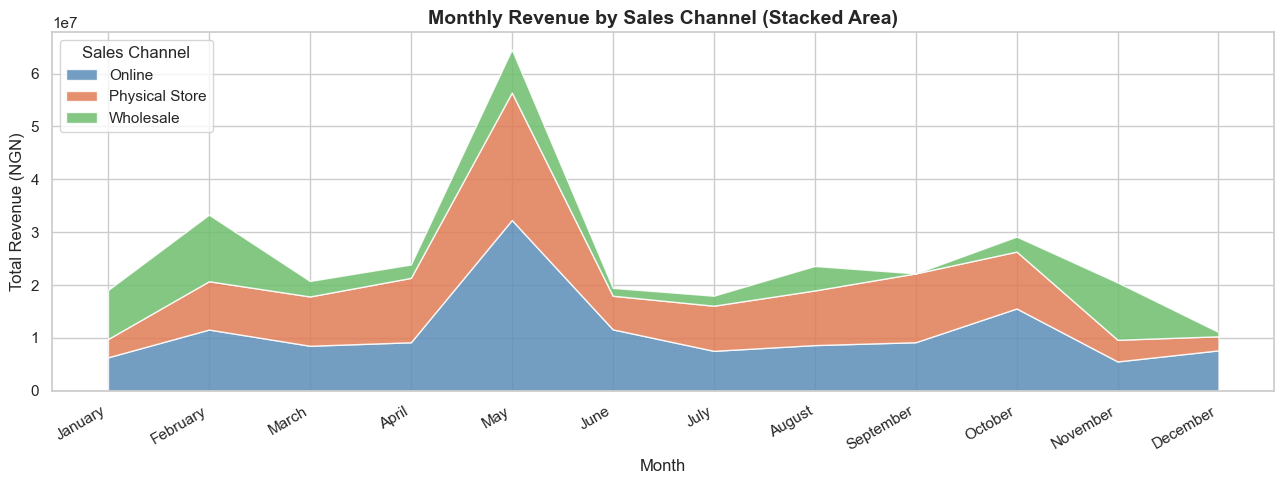

The TOTAL HEIGHT at any month = total revenue that month.
Each COLOR shows each channel's contribution to that total.


In [27]:
# ── AREA CHART: Monthly Revenue by Sales Channel (Stacked) ──────────────────

# Pivot: rows = months, columns = channels
pivot = (df.assign(Month=pd.Categorical(df['Month'], categories=month_order, ordered=True))
           .groupby(['Month','Sales_Channel'])['Revenue_NGN']
           .sum()
           .unstack(fill_value=0)
           .sort_index())

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(range(len(pivot)), pivot.T.values,
             labels=pivot.columns.tolist(),
             colors=['#5B8DB8','#E07B54','#6DBE6D'],
             alpha=0.85)

ax.set_xticks(range(len(pivot)))
ax.set_xticklabels(pivot.index, rotation=30, ha='right')
ax.set_title("Monthly Revenue by Sales Channel (Stacked Area)", fontsize=14, fontweight='bold')
ax.set_xlabel("Month"); ax.set_ylabel("Total Revenue (NGN)")
ax.legend(loc='upper left', title='Sales Channel')
plt.tight_layout()
plt.show()
print("The TOTAL HEIGHT at any month = total revenue that month.")
print("Each COLOR shows each channel's contribution to that total.")


---
### 4.9 Heatmap

#### What is it?
A **heatmap** uses **color intensity** to represent values in a matrix (table). Darker or brighter colors = higher or lower values.

#### Why does it exist?
To show **patterns in a matrix of numbers** at a glance — especially **correlations** between many variables simultaneously.

#### When to USE it:
- **Correlation matrix** — which pairs of variables are related?
- **Pivot table visualization** — e.g., revenue by state AND month
- Showing patterns across **two categorical dimensions**

#### How to interpret it:
- In a **correlation heatmap**: values range from −1 to +1
  - **Dark red/warm** = strong positive correlation
  - **Dark blue/cool** = strong negative correlation
  - **White/pale** = no correlation
- The **diagonal** is always 1.0 (a variable perfectly correlates with itself)


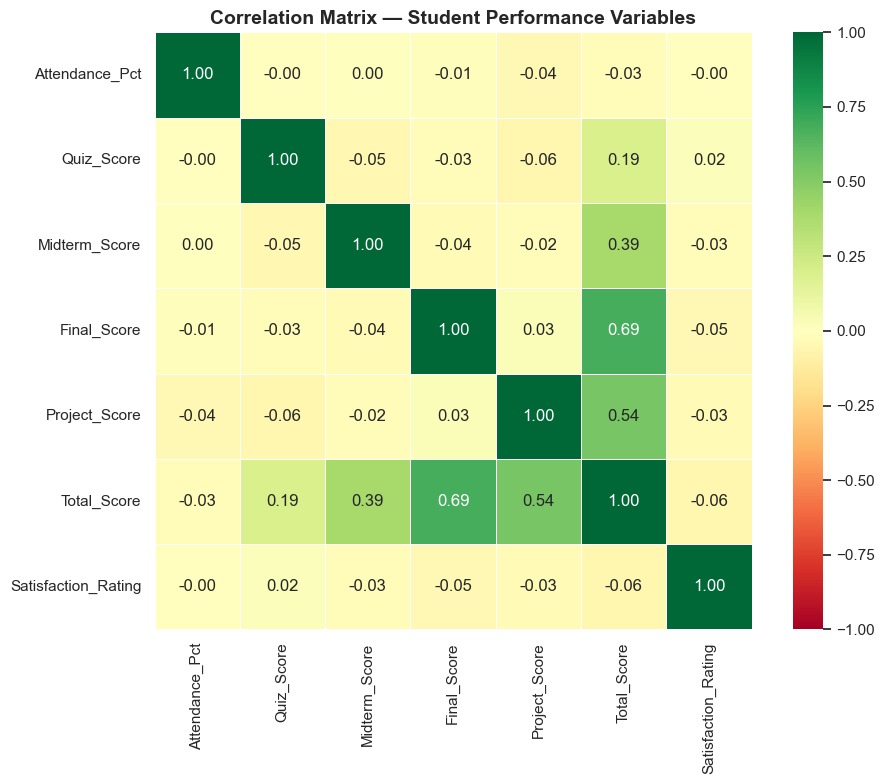

How to read this: Find a cell at the intersection of two variables.
The number shows how strongly they move together.
Values close to 1.0 = they rise and fall together (positive correlation).
Values close to -1.0 = when one rises, the other falls (negative correlation).


In [28]:
# ── HEATMAP Example 1: Correlation Matrix — Student Dataset ──────────────────

numeric_cols = ['Attendance_Pct','Quiz_Score','Midterm_Score',
                'Final_Score','Project_Score','Total_Score','Satisfaction_Rating']
corr_matrix = students[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            square=True, ax=ax)

ax.set_title("Correlation Matrix — Student Performance Variables", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("How to read this: Find a cell at the intersection of two variables.")
print("The number shows how strongly they move together.")
print("Values close to 1.0 = they rise and fall together (positive correlation).")
print("Values close to -1.0 = when one rises, the other falls (negative correlation).")


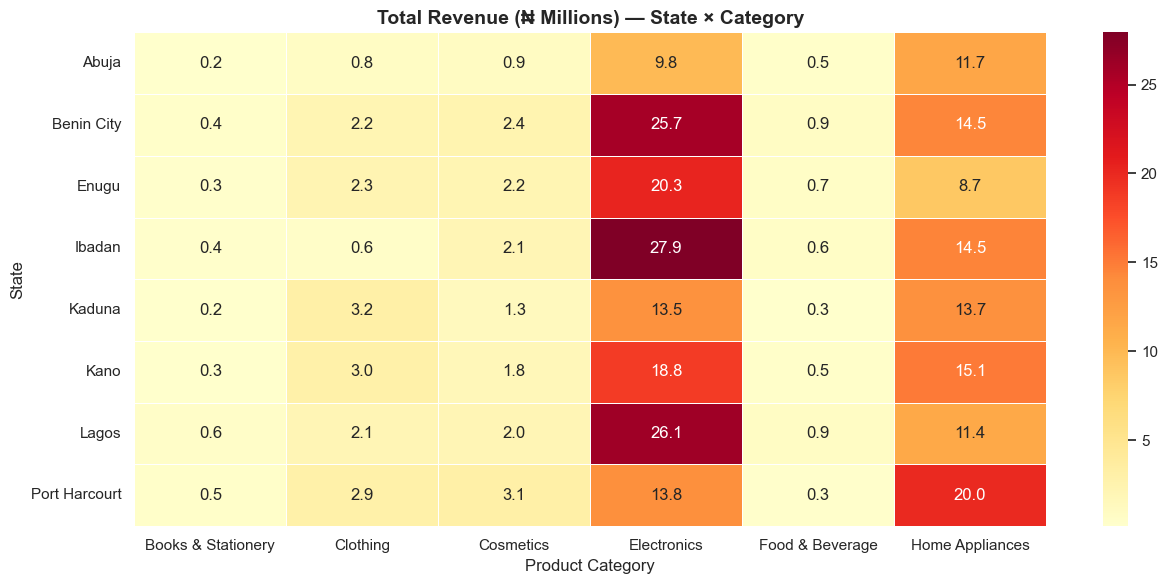

Bright/dark cells = high revenue. Pale cells = low revenue.
This reveals which State-Category combinations are the strongest markets.


In [29]:
# ── HEATMAP Example 2: Revenue pivot — State × Category ─────────────────────

pivot_rev = df.pivot_table(values='Revenue_NGN', index='State',
                            columns='Category', aggfunc='sum') / 1e6  # in millions

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot_rev, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax)

ax.set_title("Total Revenue (₦ Millions) — State × Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Product Category"); ax.set_ylabel("State")
plt.tight_layout()
plt.show()
print("Bright/dark cells = high revenue. Pale cells = low revenue.")
print("This reveals which State-Category combinations are the strongest markets.")


---
### 4.10 Pair Plot (Scatter Matrix)

#### What is it?
A **pair plot** automatically creates a grid of scatter plots for **every combination of numerical variables**. The diagonal shows the distribution of each variable (histogram or KDE).

#### Why does it exist?
To quickly explore **all pairwise relationships** in a dataset at once — without creating 15 separate scatter plots manually.

#### When to USE it:
- **Early-stage exploratory data analysis (EDA)**
- When you want to see everything at once
- When you have 3–8 numerical variables

#### When NOT to use it:
- With many variables (more than 8 becomes impossible to read)
- In final presentations (too dense — pick specific charts instead)


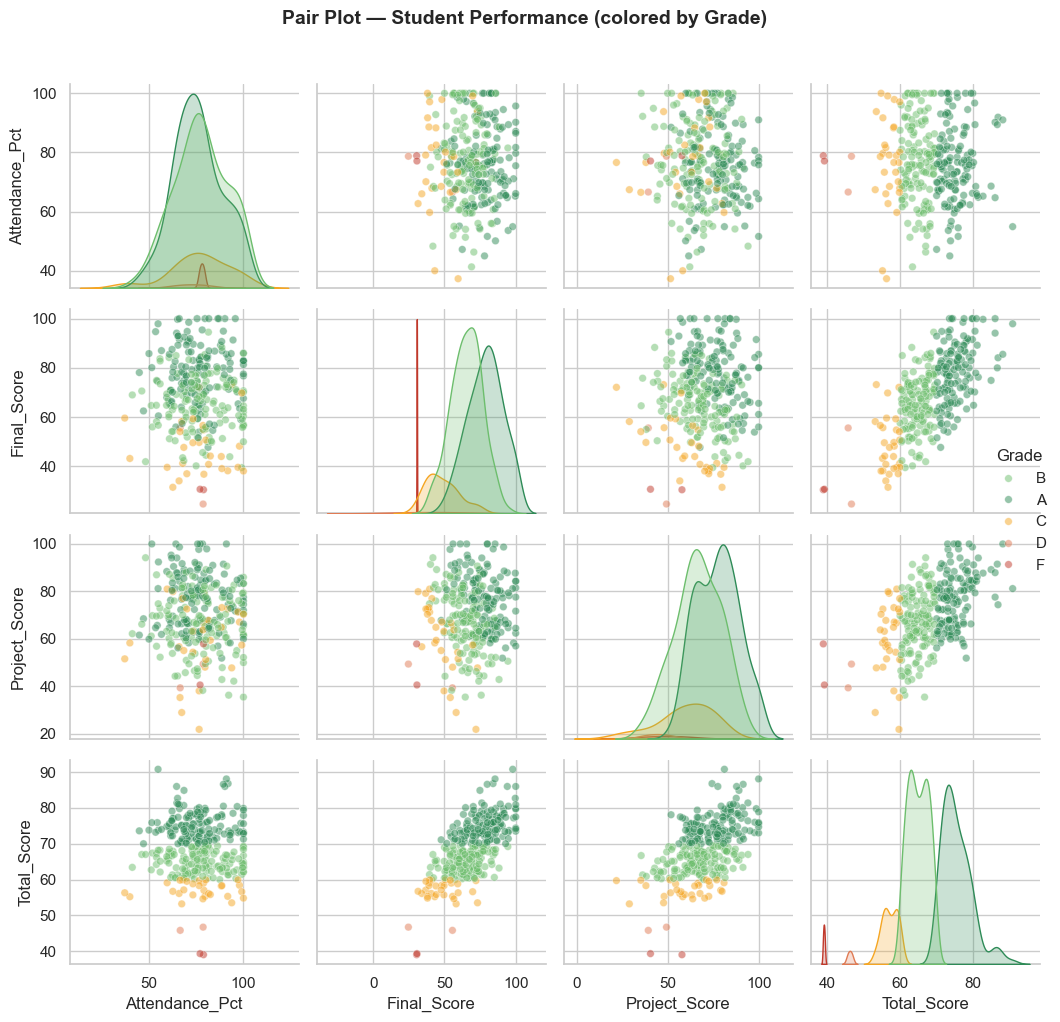

Diagonal = distribution of each variable
Off-diagonal = scatter plot of every pair
Color = Grade group. This helps spot if high-grade students cluster differently.


In [30]:
# ── PAIR PLOT: Student performance numeric variables ──────────────────────────

cols_for_pair = ['Attendance_Pct','Final_Score','Project_Score','Total_Score']

pair_data = students[cols_for_pair + ['Grade']].copy()

g = sns.pairplot(pair_data, hue='Grade',
                 palette={'A':'#2E8B57','B':'#6DBE6D','C':'#F5A623','D':'#E07B54','F':'#C0392B'},
                 plot_kws={'alpha':0.5, 's':30},
                 diag_kind='kde',
                 corner=False)

g.figure.suptitle("Pair Plot — Student Performance (colored by Grade)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Diagonal = distribution of each variable")
print("Off-diagonal = scatter plot of every pair")
print("Color = Grade group. This helps spot if high-grade students cluster differently.")


---
### 4.11 KDE Plot (Kernel Density Estimate)

#### What is it?
A **KDE plot** is a smoothed version of a histogram. Instead of bars, it draws a smooth curve showing where values are **most concentrated**.

#### When to USE it:
- When you want a **smoother view** of a distribution than a histogram gives
- **Comparing distributions** of multiple groups on the same chart
- When histograms look jagged due to few data points

#### How to interpret it:
- **Peak (highest point)** = the most common value range
- **Wide spread** = high variability
- **Two peaks** = bimodal (two groups)


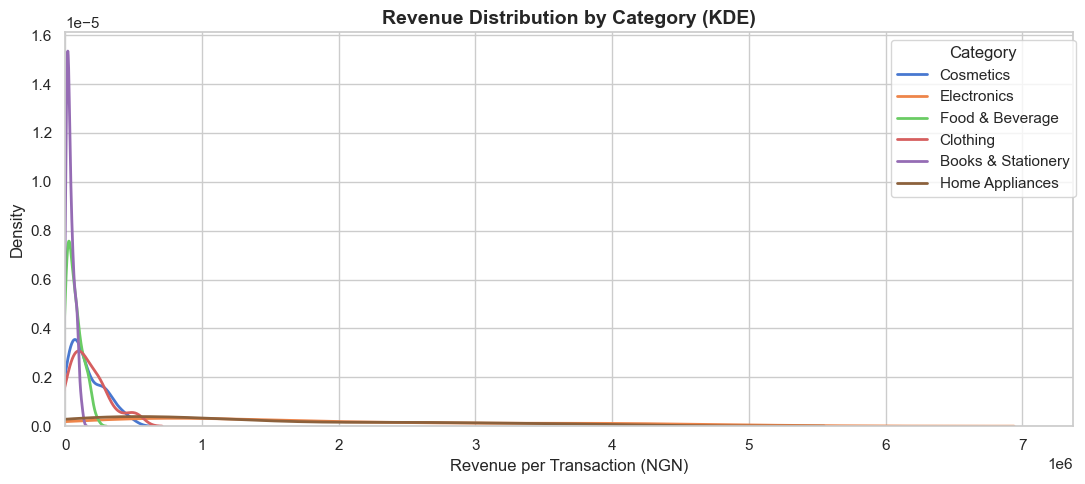

Peaks far to the right = high-value transactions.
Categories with peaks near zero = mostly low-value transactions.


In [31]:
# ── KDE PLOT Example 1: Distribution of Revenue across categories ─────────────

fig, ax = plt.subplots(figsize=(11, 5))

for cat in df['Category'].unique():
    subset = df[df['Category'] == cat]['Revenue_NGN']
    sns.kdeplot(subset, ax=ax, label=cat, linewidth=2, fill=False)

ax.set_title("Revenue Distribution by Category (KDE)", fontsize=14, fontweight='bold')
ax.set_xlabel("Revenue per Transaction (NGN)"); ax.set_ylabel("Density")
ax.legend(title="Category", bbox_to_anchor=(1.01, 1))
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()
print("Peaks far to the right = high-value transactions.")
print("Categories with peaks near zero = mostly low-value transactions.")


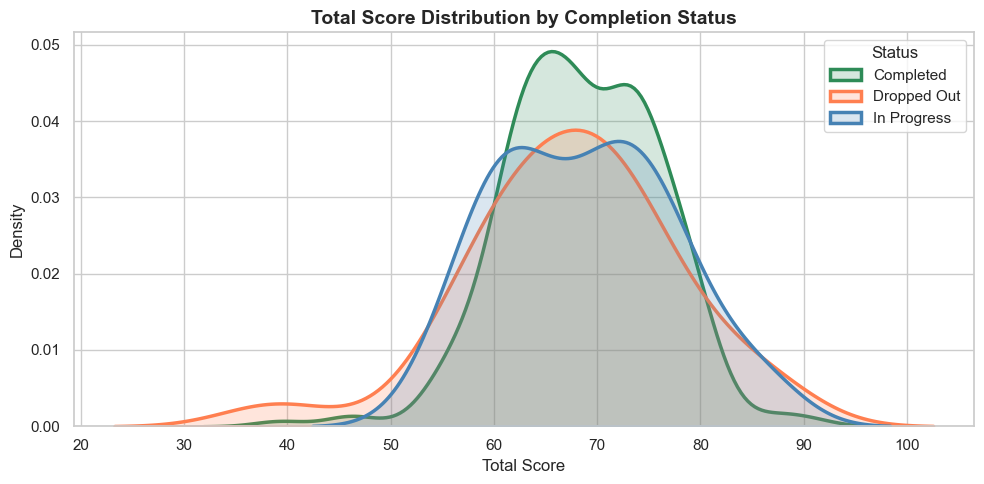

In [32]:
# ── KDE PLOT Example 2: Total Score by Completion Status ─────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

palette = {'Completed':'seagreen','Dropped Out':'coral','In Progress':'steelblue'}
for status, grp in students.groupby('Completion_Status'):
    sns.kdeplot(grp['Total_Score'], ax=ax, label=status,
                color=palette[status], linewidth=2.5, fill=True, alpha=0.2)

ax.set_title("Total Score Distribution by Completion Status", fontsize=14, fontweight='bold')
ax.set_xlabel("Total Score"); ax.set_ylabel("Density")
ax.legend(title="Status")
plt.tight_layout()
plt.show()


---
### 4.12 Count Plot

#### What is it?
A **count plot** is a bar chart that **counts how many records** fall into each category — you don't need to pre-aggregate the data.

#### When to USE it:
- Quickly seeing how **balanced or imbalanced** your categories are
- Checking **sample sizes** per group
- Exploratory data analysis on categorical columns


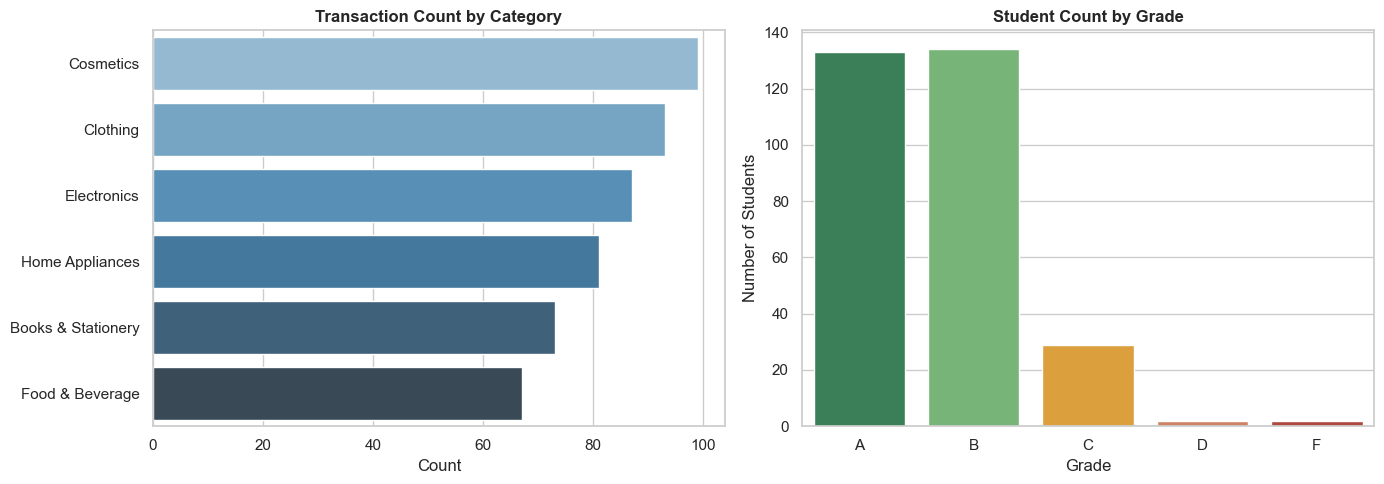

In [33]:
# ── COUNT PLOT Example 1: Number of transactions per Category ────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, y='Category', ax=axes[0],
              order=df['Category'].value_counts().index,
              palette='Blues_d')
axes[0].set_title("Transaction Count by Category", fontweight='bold')
axes[0].set_xlabel("Count"); axes[0].set_ylabel("")

sns.countplot(data=students, x='Grade', ax=axes[1],
              order=['A','B','C','D','F'],
              palette=['#2E8B57','#6DBE6D','#F5A623','#E07B54','#C0392B'])
axes[1].set_title("Student Count by Grade", fontweight='bold')
axes[1].set_xlabel("Grade"); axes[1].set_ylabel("Number of Students")

plt.tight_layout()
plt.show()


---
### 4.13 Bubble Chart

#### What is it?
A **bubble chart** is a scatter plot where a **third variable** is encoded in the **size** of each dot (bubble). So it shows three variables simultaneously: X position, Y position, and bubble size.

#### When to USE it:
- When you have three numerical variables to compare
- When one variable represents **scale or magnitude** (e.g., market size, total revenue)


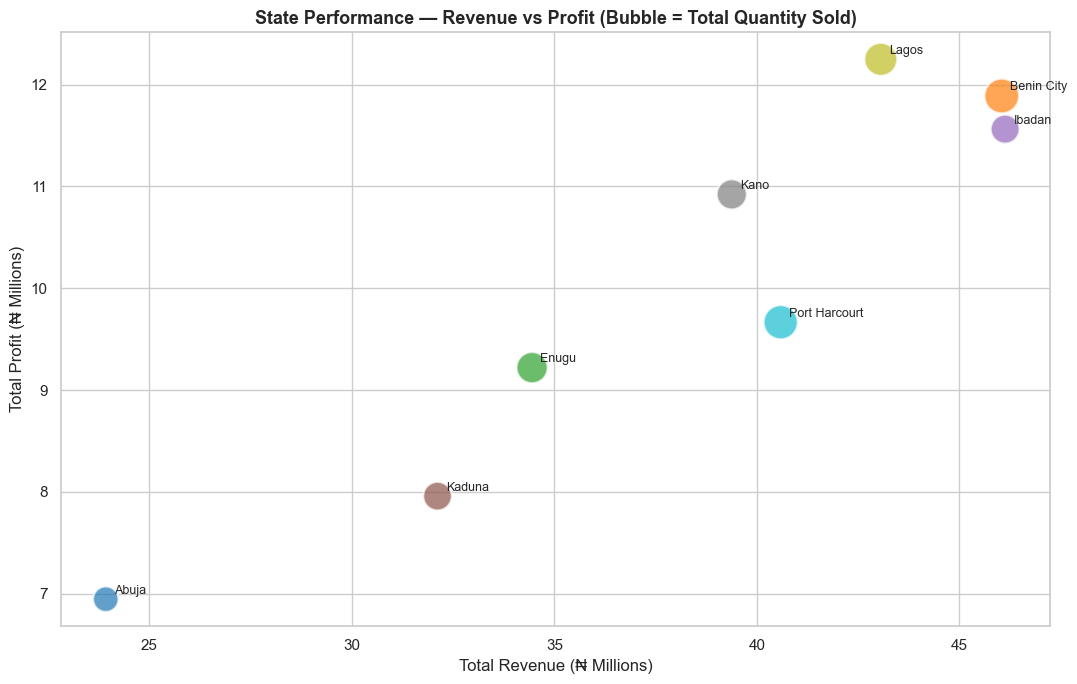

X-axis = Revenue | Y-axis = Profit | Bubble SIZE = Total Quantity Sold


In [34]:
# ── BUBBLE CHART: State — Revenue, Profit, Quantity ─────────────────────────

state_summary = df.groupby('State').agg(
    Revenue=('Revenue_NGN','sum'),
    Profit=('Profit_NGN','sum'),
    Quantity=('Quantity_Sold','sum'),
    Transactions=('Revenue_NGN','count')
).reset_index()

fig, ax = plt.subplots(figsize=(11, 7))

bubble = ax.scatter(state_summary['Revenue']/1e6,
                    state_summary['Profit']/1e6,
                    s=state_summary['Quantity']*0.8,
                    c=range(len(state_summary)),
                    cmap='tab10', alpha=0.7, edgecolors='white', linewidths=1.5)

for _, row in state_summary.iterrows():
    ax.annotate(row['State'],
                (row['Revenue']/1e6, row['Profit']/1e6),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_title("State Performance — Revenue vs Profit (Bubble = Total Quantity Sold)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Total Revenue (₦ Millions)"); ax.set_ylabel("Total Profit (₦ Millions)")
plt.tight_layout()
plt.show()
print("X-axis = Revenue | Y-axis = Profit | Bubble SIZE = Total Quantity Sold")


---
### 4.14 Treemap

#### What is it?
A **treemap** displays hierarchical data as nested rectangles. Each rectangle's **area** represents a value (e.g., revenue). It is excellent for showing **part-to-whole** relationships across a hierarchy.

#### When to USE it:
- Visualizing **hierarchical data** (category → sub-category)
- Showing **relative sizes** of many items at once
- When pie charts have too many slices


In [35]:
# ── TREEMAP: Revenue by State and Category (using Plotly) ────────────────────

state_cat = df.groupby(['State','Category'])['Revenue_NGN'].sum().reset_index()
state_cat.columns = ['State','Category','Revenue']

fig = px.treemap(state_cat,
                 path=['State','Category'],
                 values='Revenue',
                 color='Revenue',
                 color_continuous_scale='Blues',
                 title='Revenue Treemap: State → Category')

fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()
print("Larger rectangle = higher revenue. Nested structure shows State > Category hierarchy.")


Larger rectangle = higher revenue. Nested structure shows State > Category hierarchy.


---
### 4.15 Funnel Chart

#### What is it?
A **funnel chart** shows a process where values **decrease at each stage**. The widest bar at the top represents the starting value; subsequent bars shrink as data drops out at each stage.

#### When to USE it:
- Sales or marketing pipelines
- Conversion tracking (how many leads became customers?)
- Any multi-step process where numbers reduce at each step


In [36]:
# ── FUNNEL CHART: Simulated Customer Journey Funnel ──────────────────────────

funnel_data = {
    'Stage':  ['Website Visitors','Product Views','Added to Cart','Checkout Started','Completed Purchase'],
    'Count':  [10000, 6200, 3400, 1800, 950]
}
df_funnel = pd.DataFrame(funnel_data)

fig = go.Figure(go.Funnel(
    y=df_funnel['Stage'],
    x=df_funnel['Count'],
    textinfo='value+percent initial',
    marker=dict(color=['#003f5c','#2f4b7c','#665191','#a05195','#f95d6a']),
))
fig.update_layout(title='Customer Conversion Funnel', height=450)
fig.show()
print("Each stage shows how many customers continued. Drop-off between stages = conversion loss.")


Each stage shows how many customers continued. Drop-off between stages = conversion loss.


---
### 4.16 Waterfall Chart

#### What is it?
A **waterfall chart** shows how an initial value is **increased or decreased** by a series of intermediate values to arrive at a final result. Positive bars go up, negative bars go down.

#### When to USE it:
- Showing **revenue vs costs → profit**
- Budget variance analysis
- Showing cumulative impact of sequential changes


In [37]:
# ── WATERFALL CHART: Revenue breakdown for 2023 ──────────────────────────────

labels   = ['Gross Revenue','Discounts','Returns','Net Revenue','COGS','Gross Profit']
values   = [850000000, -62000000, -18000000, 0, -420000000, 0]
measure  = ['absolute','relative','relative','total','relative','total']

fig = go.Figure(go.Waterfall(
    name="2023 P&L",
    orientation="v",
    measure=measure,
    x=labels,
    y=values,
    text=[f"₦{abs(v)/1e6:.0f}M" for v in [850e6, -62e6, -18e6, 770e6, -420e6, 350e6]],
    textposition="outside",
    connector={"line": {"color": "gray", "dash":"dot"}},
    increasing={"marker":{"color":"#27AE60"}},
    decreasing={"marker":{"color":"#E74C3C"}},
    totals={"marker":{"color":"#2980B9"}},
))
fig.update_layout(title="2023 P&L Waterfall — Nigeria Retail", height=480)
fig.show()


---
### 4.17 Gantt Chart

#### What is it?
A **Gantt chart** shows a **project timeline** with tasks as horizontal bars. Each bar spans the task's start and end date.

#### When to USE it:
- Project planning and management
- Showing task dependencies and timelines
- Tracking progress against a schedule


In [38]:
# ── GANTT CHART: Prodigy Training Hub — Q3 Course Delivery Plan ──────────────

gantt_data = [
    dict(Task='Python Fundamentals',     Start='2024-07-01', Finish='2024-07-14', Resource='Python'),
    dict(Task='Data Analysis w/ Pandas', Start='2024-07-15', Finish='2024-07-28', Resource='Python'),
    dict(Task='Data Visualization',      Start='2024-07-29', Finish='2024-08-11', Resource='Python'),
    dict(Task='ML Introduction',         Start='2024-08-12', Finish='2024-08-25', Resource='Python'),
    dict(Task='Power BI Fundamentals',   Start='2024-07-01', Finish='2024-07-21', Resource='Power BI'),
    dict(Task='DAX & Data Modeling',     Start='2024-07-22', Finish='2024-08-11', Resource='Power BI'),
    dict(Task='Project Management Intro',Start='2024-08-01', Finish='2024-08-18', Resource='PM'),
    dict(Task='MS Project Practical',    Start='2024-08-19', Finish='2024-09-01', Resource='PM'),
]

df_gantt = pd.DataFrame(gantt_data)

color_map = {'Python':'#5B8DB8','Power BI':'#E07B54','PM':'#6DBE6D'}

fig = px.timeline(df_gantt, x_start='Start', x_end='Finish', y='Task',
                  color='Resource', color_discrete_map=color_map,
                  title='Prodigy Training Hub — Q3 2024 Delivery Gantt')
fig.update_yaxes(autorange='reversed')
fig.update_layout(height=450, legend_title='Programme')
fig.show()


---
### 4.18 Radar Chart (Spider Chart)

#### What is it?
A **radar chart** (also called a spider chart) displays multiple variables on **axes radiating from a central point**. Each axis represents one variable, and you plot values along each axis and connect them into a polygon.

#### When to USE it:
- Comparing a subject across **multiple dimensions** simultaneously
- Performance profiling (e.g., a student's scores across Quiz, Midterm, Final, Project, Attendance)
- Comparing two or more entities on the same dimensions


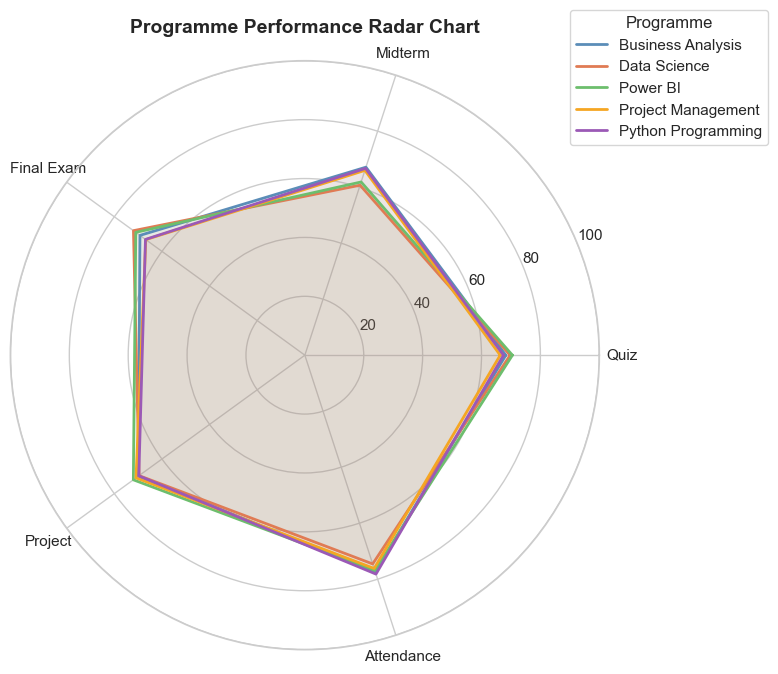

A programme with a LARGER polygon = stronger performance across all dimensions.


In [39]:
# ── RADAR CHART: Programme average scores comparison ─────────────────────────

categories = ['Quiz_Score','Midterm_Score','Final_Score','Project_Score','Attendance_Pct']
prog_means = students.groupby('Programme')[categories].mean()

# Scale Attendance to 0-100 for fair comparison (already is, but good practice)
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#5B8DB8','#E07B54','#6DBE6D','#F5A623','#9B59B6']

for idx, (prog, row) in enumerate(prog_means.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=prog)
    ax.fill(angles, values, color=colors[idx], alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Quiz','Midterm','Final Exam','Project','Attendance'], fontsize=11)
ax.set_ylim(0, 100)
ax.set_title("Programme Performance Radar Chart", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title='Programme')
plt.tight_layout()
plt.show()
print("A programme with a LARGER polygon = stronger performance across all dimensions.")


---
## Section 5 — Interactive Visualization with Plotly

Plotly charts are **interactive** — hover over data points, zoom in, click legend items to toggle series.

These are ideal for presentations and dashboards.


In [40]:
# ── INTERACTIVE LINE: Monthly Revenue by Channel ─────────────────────────────

channel_month2 = (df.assign(Month=pd.Categorical(df['Month'], categories=month_order, ordered=True))
                    .groupby(['Month','Sales_Channel'])['Revenue_NGN']
                    .sum()
                    .reset_index()
                    .sort_values('Month'))

fig = px.line(channel_month2, x='Month', y='Revenue_NGN',
              color='Sales_Channel', markers=True,
              title='Monthly Revenue by Sales Channel (Interactive)',
              labels={'Revenue_NGN':'Revenue (NGN)','Month':'Month','Sales_Channel':'Channel'})
fig.update_traces(line_width=2.5)
fig.show()


In [41]:
# ── INTERACTIVE BAR: Top States by Revenue ───────────────────────────────────

state_rev2 = df.groupby('State')['Revenue_NGN'].sum().sort_values(ascending=False).reset_index()

fig = px.bar(state_rev2, x='State', y='Revenue_NGN',
             color='Revenue_NGN', color_continuous_scale='Blues',
             title='Total Revenue by State (Interactive)',
             labels={'Revenue_NGN':'Total Revenue (NGN)'})
fig.update_layout(coloraxis_showscale=False)
fig.show()


In [42]:
# ── INTERACTIVE SCATTER: Student Attendance vs Final Score ────────────────────
# Option A
# Install statsmodels (Recommended, keeps the trendline)
# Adding these first two lines of code and running it within the cell will stop the cell from failing
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])
print("statsmodels installed.")
fig = px.scatter(students, x='Attendance_Pct', y='Final_Score',
                 color='Programme', size='Total_Score',
                 hover_data=['Student_ID','Grade','Completion_Status'],
                 trendline='ols',
                 title='Attendance vs Final Score — Hover for Student Details',
                 labels={'Attendance_Pct':'Attendance (%)','Final_Score':'Final Score'})
fig.show()


statsmodels installed.


In [43]:
# ── INTERACTIVE SCATTER: Student Attendance vs Final Score ────────────────────
# Option B - Remove the trendline (No install needed)
# If you don't want to install anything, replace trendline='ols' with nothing
fig = px.scatter(students, x='Attendance_Pct', y='Final_Score',
                 color='Programme', size='Total_Score',
                 hover_data=['Student_ID','Grade','Completion_Status'],
                 title='Attendance vs Final Score — Hover for Student Details',
                 labels={'Attendance_Pct':'Attendance (%)','Final_Score':'Final Score'})
fig.show()

Why does this happen?

`Plotly's trendline='ols'` means `Ordinary Least Squares regression line` - it uses statsmodels under the hood to calculate the line of best fit. Plotly does not bundle it automatically because not everyone needs it, so it is a separate install.

In [44]:
# ── INTERACTIVE BOX PLOT: Score by Programme ─────────────────────────────────

fig = px.box(students, x='Programme', y='Total_Score', color='Programme',
             points='outliers',
             title='Total Score Distribution by Programme (Interactive Box Plot)',
             labels={'Total_Score':'Total Score','Programme':'Programme'})
fig.update_layout(showlegend=False)
fig.show()


---
# SECTION 6 — PRACTICAL PROJECT A: Nigeria Retail Sales (CSV)

## Complete End-to-End Visualization Analysis

This section simulates a **real data analyst task**:
> *"You have been given the Nigeria Retail Sales dataset. Read it, explore it, and produce a comprehensive set of visualizations to answer management's key questions."*

### Business Questions We Will Answer:
1. Which state generates the most revenue and profit?
2. How does revenue trend across months?
3. Which product categories are most profitable?
4. Is there a relationship between discount and revenue?
5. What is the distribution of customer demographics?
6. Which sales channel performs best?
7. Do ratings differ by category?
8. What are the outlier transactions?

---


In [45]:
# ═══ PRACTICAL A — Step 1: Load and Verify Data ══════════════════════════════

df_retail = pd.read_csv("nigeria_retail_sales.csv", parse_dates=['Date'])

print("Shape:", df_retail.shape)
print()
print("Missing values:")
print(df_retail.isnull().sum())
print()
print("Column Types:")
print(df_retail.dtypes)


Shape: (500, 18)

Missing values:
Date                0
Month               0
Quarter             0
Day_of_Week         0
State               0
Category            0
Sales_Channel       0
Payment_Method      0
Customer_Gender     0
Customer_Age        0
Unit_Price_NGN      0
Quantity_Sold       0
Discount_Percent    0
Revenue_NGN         0
Profit_Margin       0
Profit_NGN          0
Customer_Rating     0
Item_Returned       0
dtype: int64

Column Types:
Date                datetime64[ns]
Month                       object
Quarter                     object
Day_of_Week                 object
State                       object
Category                    object
Sales_Channel               object
Payment_Method              object
Customer_Gender             object
Customer_Age                 int64
Unit_Price_NGN             float64
Quantity_Sold                int64
Discount_Percent             int64
Revenue_NGN                float64
Profit_Margin              float64
Profit_NGN       

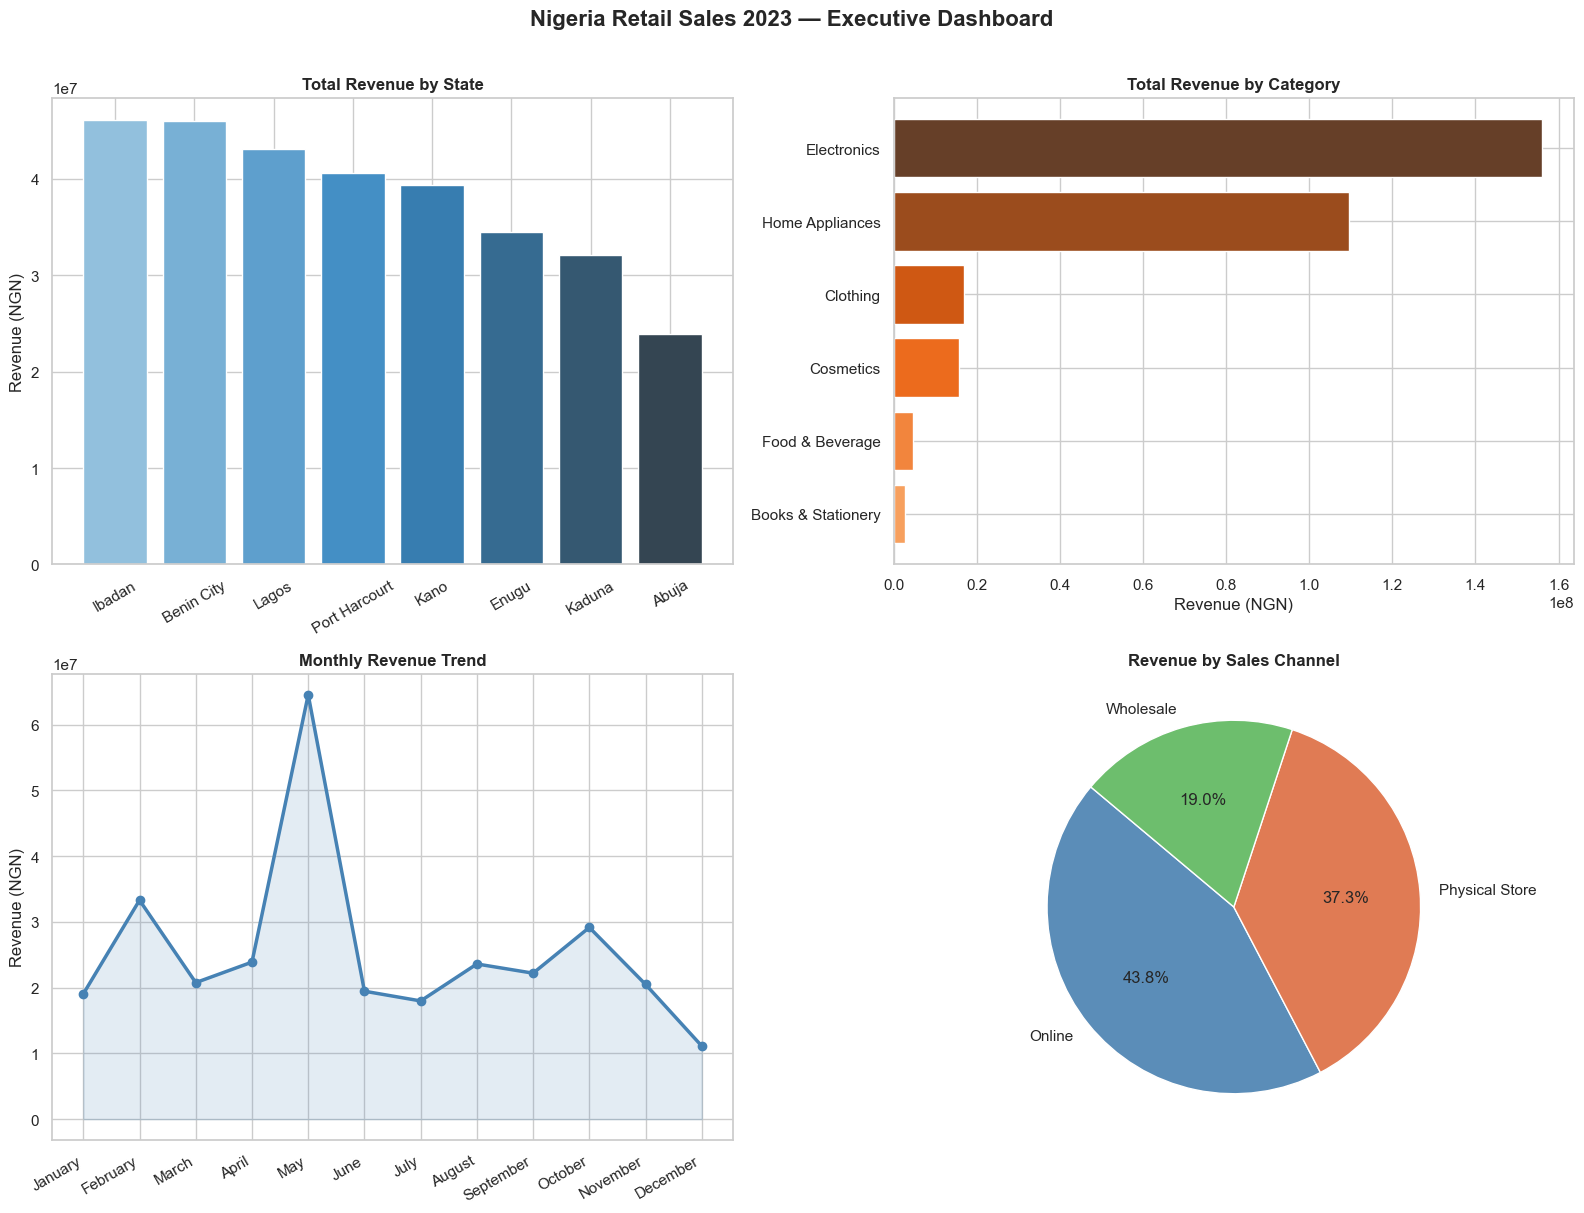

Dashboard saved as retail_dashboard.png


In [46]:
# ═══ Step 2: Overview Dashboard — 4 key charts in one figure ═════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Nigeria Retail Sales 2023 — Executive Dashboard",
             fontsize=16, fontweight='bold', y=1.01)

# Chart 1 (top-left): Revenue by State
state_r = df_retail.groupby('State')['Revenue_NGN'].sum().sort_values(ascending=False)
axes[0,0].bar(state_r.index, state_r.values, color=sns.color_palette("Blues_d", len(state_r)))
axes[0,0].set_title("Total Revenue by State", fontweight='bold')
axes[0,0].set_ylabel("Revenue (NGN)")
axes[0,0].tick_params(axis='x', rotation=30)

# Chart 2 (top-right): Revenue by Category
cat_r = df_retail.groupby('Category')['Revenue_NGN'].sum().sort_values()
axes[0,1].barh(cat_r.index, cat_r.values, color=sns.color_palette("Oranges_d", len(cat_r)))
axes[0,1].set_title("Total Revenue by Category", fontweight='bold')
axes[0,1].set_xlabel("Revenue (NGN)")

# Chart 3 (bottom-left): Monthly Revenue Trend
month_r = (df_retail.assign(Month=pd.Categorical(df_retail['Month'], categories=month_order, ordered=True))
                    .groupby('Month')['Revenue_NGN'].sum().sort_index())
axes[1,0].plot(month_r.index, month_r.values, color='steelblue', marker='o', linewidth=2.5)
axes[1,0].fill_between(range(len(month_r)), month_r.values, alpha=0.15, color='steelblue')
axes[1,0].set_xticks(range(len(month_r)))
axes[1,0].set_xticklabels(month_r.index, rotation=30, ha='right')
axes[1,0].set_title("Monthly Revenue Trend", fontweight='bold')
axes[1,0].set_ylabel("Revenue (NGN)")

# Chart 4 (bottom-right): Sales Channel Pie
channel_r = df_retail.groupby('Sales_Channel')['Revenue_NGN'].sum()
axes[1,1].pie(channel_r.values, labels=channel_r.index,
              autopct='%1.1f%%', colors=['#5B8DB8','#E07B54','#6DBE6D'],
              startangle=140)
axes[1,1].set_title("Revenue by Sales Channel", fontweight='bold')

plt.tight_layout()
plt.savefig("retail_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as retail_dashboard.png")


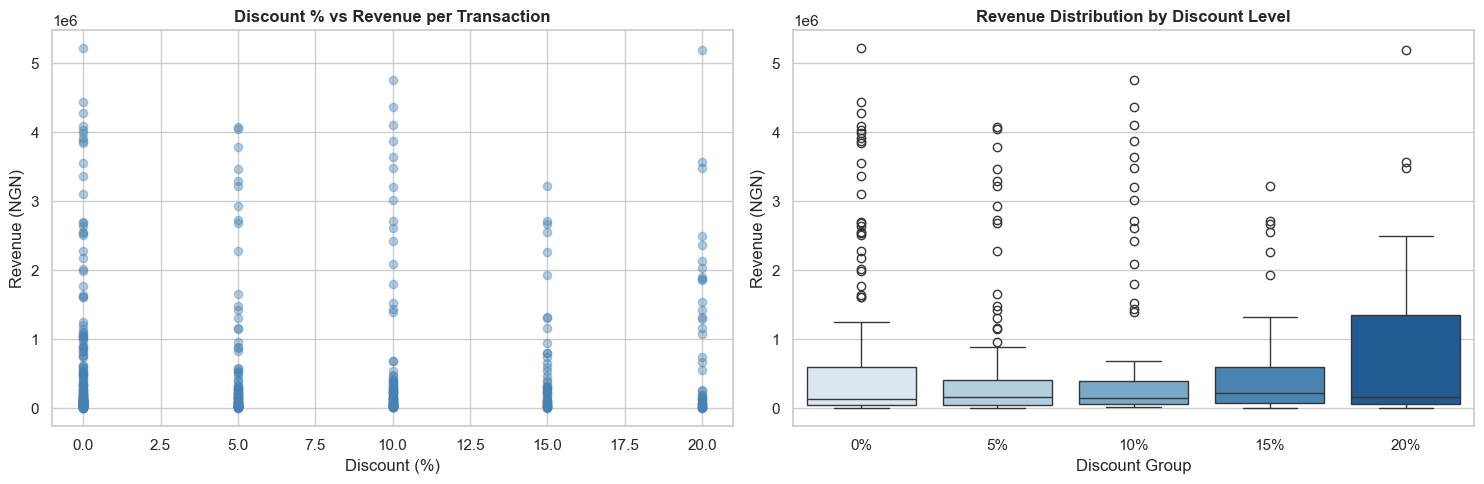

Discount  0%  |  Median Revenue: ₦     133,600  |  n=193
Discount  5%  |  Median Revenue: ₦     156,845  |  n=107
Discount 10%  |  Median Revenue: ₦     155,520  |  n=95
Discount 15%  |  Median Revenue: ₦     224,230  |  n=57
Discount 20%  |  Median Revenue: ₦     158,000  |  n=48


In [47]:
# ═══ Step 3: Discount Impact on Revenue (Scatter + Box) ═══════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: discount % vs revenue
axes[0].scatter(df_retail['Discount_Percent'], df_retail['Revenue_NGN'],
                alpha=0.4, color='steelblue', s=35)
axes[0].set_title("Discount % vs Revenue per Transaction", fontweight='bold')
axes[0].set_xlabel("Discount (%)"); axes[0].set_ylabel("Revenue (NGN)")

# Box: revenue distribution by discount level
discount_groups = df_retail.copy()
discount_groups['Discount_Group'] = discount_groups['Discount_Percent'].astype(str) + '%'
order = ['0%','5%','10%','15%','20%']
sns.boxplot(data=discount_groups, x='Discount_Group', y='Revenue_NGN',
            order=order, palette='Blues', ax=axes[1])
axes[1].set_title("Revenue Distribution by Discount Level", fontweight='bold')
axes[1].set_xlabel("Discount Group"); axes[1].set_ylabel("Revenue (NGN)")

plt.tight_layout()
plt.show()

for d in [0,5,10,15,20]:
    subset = df_retail[df_retail['Discount_Percent']==d]['Revenue_NGN']
    print(f"Discount {d:2d}%  |  Median Revenue: ₦{subset.median():>12,.0f}  |  n={len(subset)}")


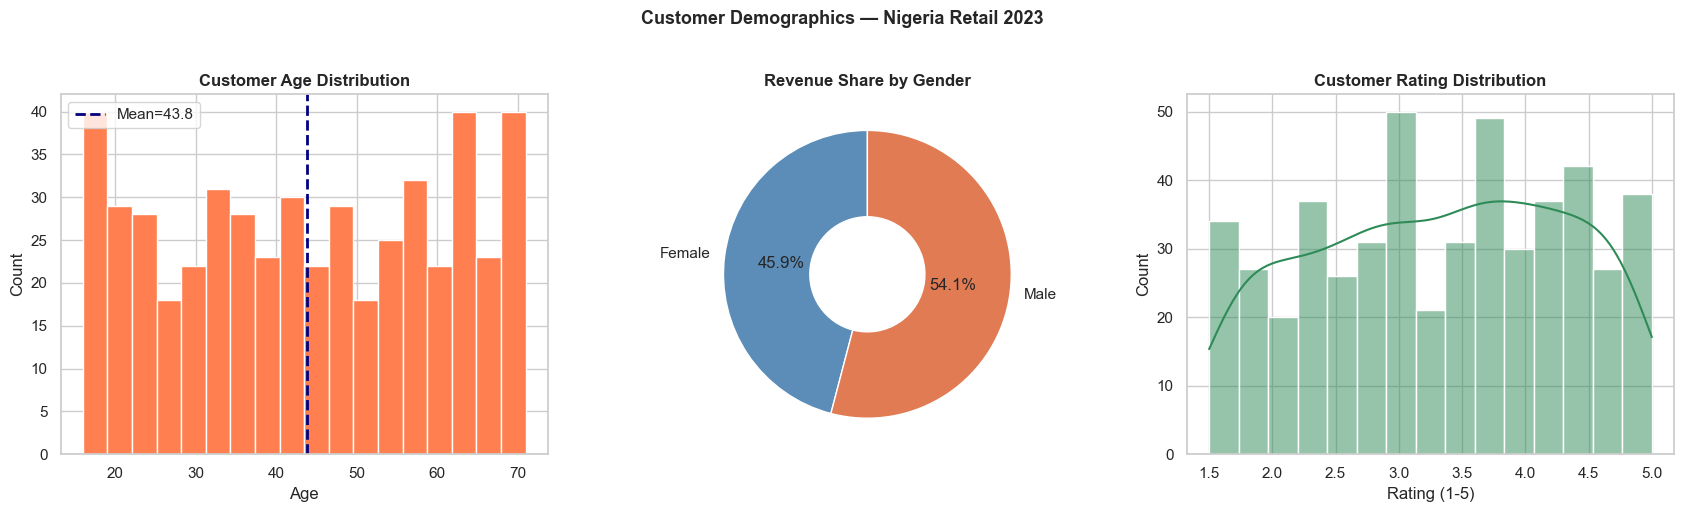

In [48]:
# ═══ Step 4: Customer Demographics Analysis ══════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Age distribution
axes[0].hist(df_retail['Customer_Age'], bins=18, color='coral', edgecolor='white')
axes[0].axvline(df_retail['Customer_Age'].mean(), color='navy', linestyle='--', linewidth=2,
                label=f"Mean={df_retail['Customer_Age'].mean():.1f}")
axes[0].set_title("Customer Age Distribution", fontweight='bold')
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Count")
axes[0].legend()

# Gender split
gender_rev = df_retail.groupby('Customer_Gender')['Revenue_NGN'].sum()
axes[1].pie(gender_rev, labels=gender_rev.index, autopct='%1.1f%%',
            colors=['#5B8DB8','#E07B54'], startangle=90,
            wedgeprops=dict(width=0.6))
axes[1].set_title("Revenue Share by Gender", fontweight='bold')

# Rating distribution
sns.histplot(df_retail['Customer_Rating'], bins=15, kde=True,
             color='seagreen', ax=axes[2])
axes[2].set_title("Customer Rating Distribution", fontweight='bold')
axes[2].set_xlabel("Rating (1-5)"); axes[2].set_ylabel("Count")

plt.suptitle("Customer Demographics — Nigeria Retail 2023", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


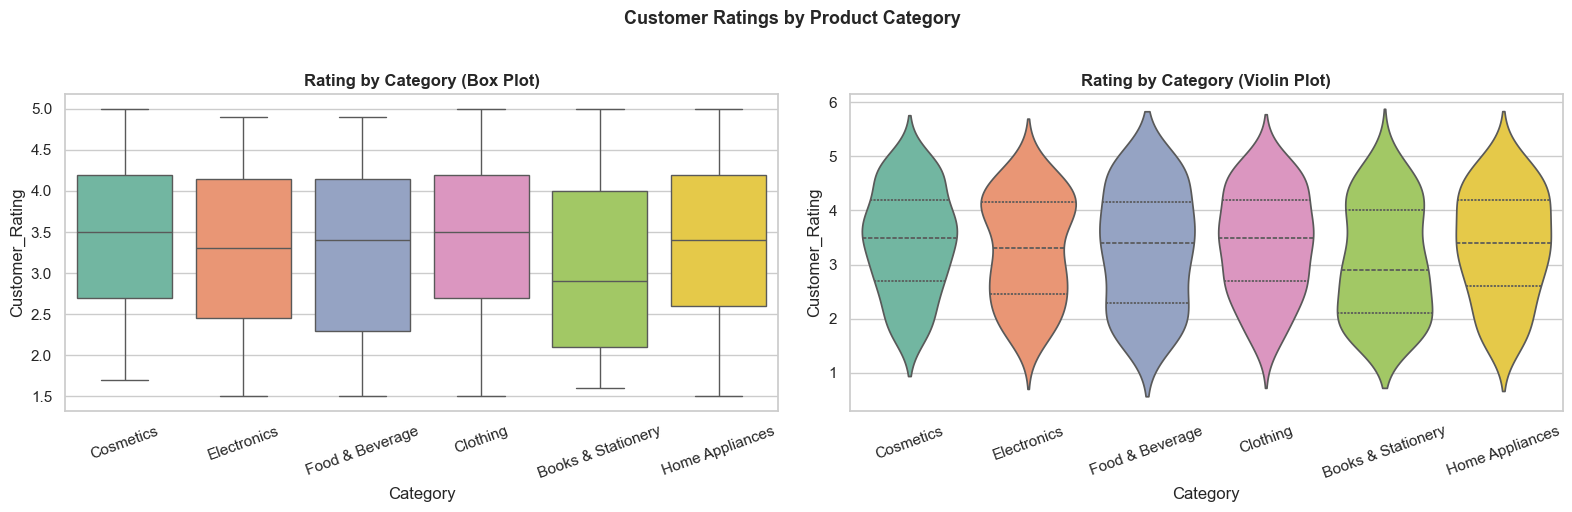

In [49]:
# ═══ Step 5: Rating by Category (Box + Violin side-by-side) ══════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_retail, x='Category', y='Customer_Rating',
            palette='Set2', ax=axes[0])
axes[0].set_title("Rating by Category (Box Plot)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

sns.violinplot(data=df_retail, x='Category', y='Customer_Rating',
               palette='Set2', inner='quartile', ax=axes[1])
axes[1].set_title("Rating by Category (Violin Plot)", fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle("Customer Ratings by Product Category", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


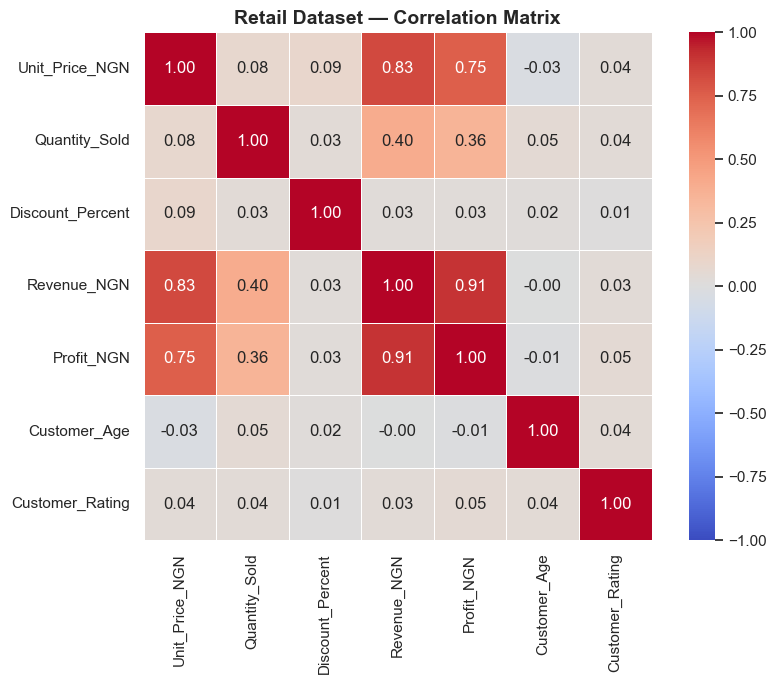

Key insight: What is the correlation between Unit Price and Revenue?
  Unit_Price_NGN vs Revenue_NGN: r = 0.8337


In [50]:
# ═══ Step 6: Correlation Heatmap — Retail Dataset ════════════════════════════

num_cols = ['Unit_Price_NGN','Quantity_Sold','Discount_Percent',
            'Revenue_NGN','Profit_NGN','Customer_Age','Customer_Rating']
corr = df_retail[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            linecolor='white', square=True, ax=ax)
ax.set_title("Retail Dataset — Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight: What is the correlation between Unit Price and Revenue?")
print(f"  Unit_Price_NGN vs Revenue_NGN: r = {corr.loc['Unit_Price_NGN','Revenue_NGN']:.4f}")


In [51]:
# ═══ Step 7: Fully Interactive Plotly Dashboard ══════════════════════════════

from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Revenue by State","Revenue by Category",
                    "Monthly Revenue Trend","Revenue by Payment Method"),
    specs=[[{"type":"bar"},{"type":"bar"}],
           [{"type":"scatter"},{"type":"pie"}]]
)

# Panel 1
state_r2 = df_retail.groupby('State')['Revenue_NGN'].sum().sort_values(ascending=False).reset_index()
fig.add_trace(go.Bar(x=state_r2['State'], y=state_r2['Revenue_NGN'],
                     marker_color='steelblue', name='State Revenue'), row=1, col=1)

# Panel 2
cat_r2 = df_retail.groupby('Category')['Revenue_NGN'].sum().sort_values().reset_index()
fig.add_trace(go.Bar(x=cat_r2['Revenue_NGN'], y=cat_r2['Category'],
                     orientation='h', marker_color='coral', name='Category Revenue'), row=1, col=2)

# Panel 3
m_r2 = (df_retail.assign(Month=pd.Categorical(df_retail['Month'], categories=month_order, ordered=True))
                 .groupby('Month')['Revenue_NGN'].sum().sort_index().reset_index())
fig.add_trace(go.Scatter(x=m_r2['Month'], y=m_r2['Revenue_NGN'],
                         mode='lines+markers', line=dict(color='seagreen', width=2.5),
                         name='Monthly Revenue'), row=2, col=1)

# Panel 4
pay_r = df_retail.groupby('Payment_Method')['Revenue_NGN'].sum().reset_index()
fig.add_trace(go.Pie(labels=pay_r['Payment_Method'], values=pay_r['Revenue_NGN'],
                     name='Payment'), row=2, col=2)

fig.update_layout(height=750, title_text="Nigeria Retail 2023 — Interactive Dashboard", showlegend=False)
fig.show()


---
# SECTION 7 — PRACTICAL PROJECT B: Student Performance (Excel)

## Reading Multi-Sheet Excel Files & Generating Insights

This section simulates receiving an Excel workbook with **3 sheets** and producing a complete visual report.

> **Task:** Analyse Prodigy Training Hub's student performance data and present findings to management.

### Excel File Structure:
| Sheet | Contents |
|-------|---------|
| `Student_Records` | 300 individual student records |
| `Programme_Summary` | Aggregated programme-level KPIs |
| `Monthly_Enrolment` | Monthly enrolment count per programme |

---


In [52]:
# ═══ PRACTICAL B — Step 1: Read ALL sheets from Excel ════════════════════════

xl_file = "prodigy_student_performance.xlsx"

students_raw  = pd.read_excel(xl_file, sheet_name="Student_Records")
prog_summary  = pd.read_excel(xl_file, sheet_name="Programme_Summary")
monthly_enrol = pd.read_excel(xl_file, sheet_name="Monthly_Enrolment")

print("Sheet 1 — Student_Records:", students_raw.shape)
print("Sheet 2 — Programme_Summary:", prog_summary.shape)
print("Sheet 3 — Monthly_Enrolment:", monthly_enrol.shape)
print()
print(prog_summary)


Sheet 1 — Student_Records: (300, 16)
Sheet 2 — Programme_Summary: (5, 6)
Sheet 3 — Monthly_Enrolment: (12, 6)

            Programme  Students  Avg_Total  Avg_Attendance  Employment_Rate  \
0   Business Analysis        63      68.87           77.41             0.67   
1        Data Science        60      68.67           74.55             0.63   
2            Power BI        62      69.39           76.91             0.56   
3  Project Management        61      67.80           76.16             0.67   
4  Python Programming        54      67.79           78.17             0.63   

   Avg_Satisfaction  
0              3.87  
1              3.82  
2              3.82  
3              3.90  
4              4.11  


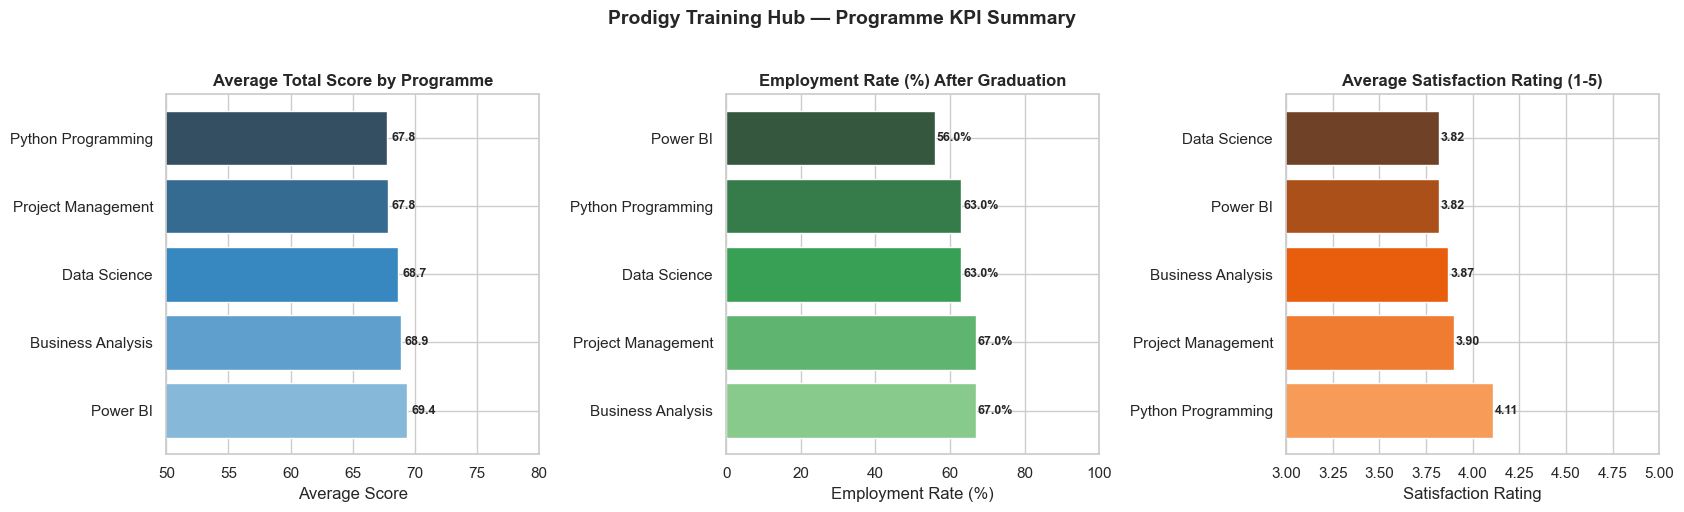

In [53]:
# ═══ Step 2: Programme Summary Bar Charts ════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Avg Total Score
prog_summary_sorted = prog_summary.sort_values('Avg_Total', ascending=False)
axes[0].barh(prog_summary_sorted['Programme'], prog_summary_sorted['Avg_Total'],
             color=sns.color_palette("Blues_d", len(prog_summary_sorted)))
axes[0].set_title("Average Total Score by Programme", fontweight='bold')
axes[0].set_xlabel("Average Score")
axes[0].set_xlim(50, 80)
for i, v in enumerate(prog_summary_sorted['Avg_Total']):
    axes[0].text(v + 0.3, i, f"{v:.1f}", va='center', fontsize=9, fontweight='bold')

# Employment Rate
prog_summary_sorted2 = prog_summary.sort_values('Employment_Rate', ascending=False)
bars2 = axes[1].barh(prog_summary_sorted2['Programme'],
                     prog_summary_sorted2['Employment_Rate'] * 100,
                     color=sns.color_palette("Greens_d", len(prog_summary_sorted2)))
axes[1].set_title("Employment Rate (%) After Graduation", fontweight='bold')
axes[1].set_xlabel("Employment Rate (%)")
axes[1].set_xlim(0, 100)
for i, v in enumerate(prog_summary_sorted2['Employment_Rate']*100):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9, fontweight='bold')

# Satisfaction
prog_summary_sorted3 = prog_summary.sort_values('Avg_Satisfaction', ascending=False)
bars3 = axes[2].barh(prog_summary_sorted3['Programme'],
                     prog_summary_sorted3['Avg_Satisfaction'],
                     color=sns.color_palette("Oranges_d", len(prog_summary_sorted3)))
axes[2].set_title("Average Satisfaction Rating (1-5)", fontweight='bold')
axes[2].set_xlabel("Satisfaction Rating")
axes[2].set_xlim(3, 5)
for i, v in enumerate(prog_summary_sorted3['Avg_Satisfaction']):
    axes[2].text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=9, fontweight='bold')

plt.suptitle("Prodigy Training Hub — Programme KPI Summary", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


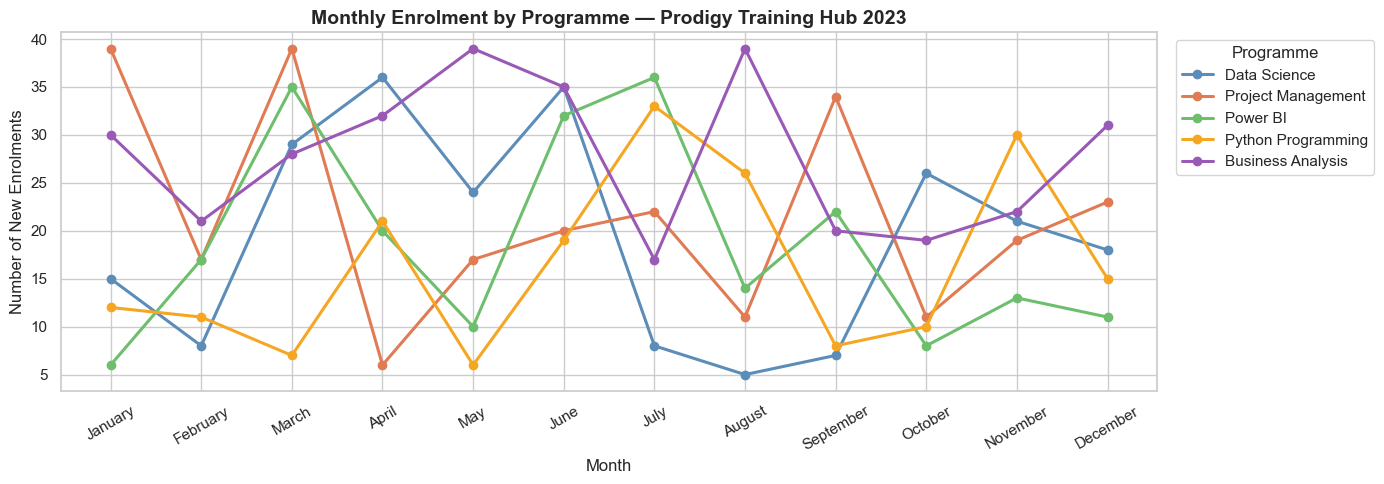

In [54]:
# ═══ Step 3: Monthly Enrolment Line Chart ════════════════════════════════════

month_order_full = ['January','February','March','April','May','June',
                    'July','August','September','October','November','December']
monthly_enrol['Month'] = pd.Categorical(monthly_enrol['Month'],
                                         categories=month_order_full, ordered=True)
monthly_enrol = monthly_enrol.sort_values('Month')

fig, ax = plt.subplots(figsize=(14, 5))
colors_prog = ['#5B8DB8','#E07B54','#6DBE6D','#F5A623','#9B59B6']
programmes_list = [c for c in monthly_enrol.columns if c != 'Month']

for i, prog in enumerate(programmes_list):
    ax.plot(monthly_enrol['Month'], monthly_enrol[prog],
            marker='o', linewidth=2.2, label=prog, color=colors_prog[i])

ax.set_title("Monthly Enrolment by Programme — Prodigy Training Hub 2023",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Month"); ax.set_ylabel("Number of New Enrolments")
ax.tick_params(axis='x', rotation=30)
ax.legend(title="Programme", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()


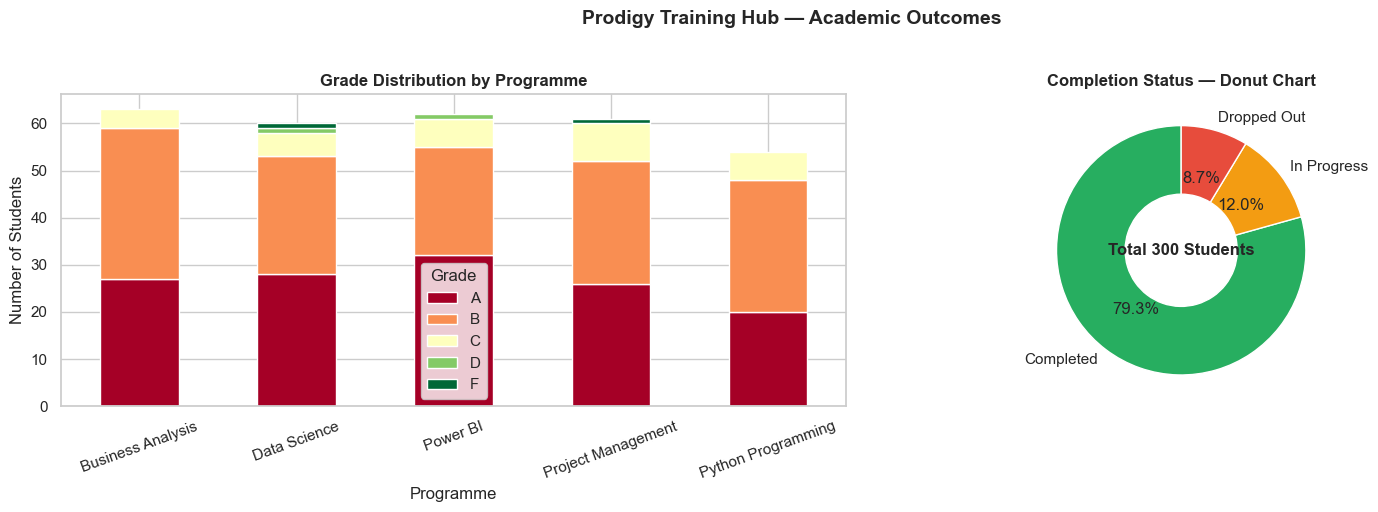

In [55]:
# ═══ Step 4: Grade Distribution — Stacked + Completion Status ════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grade by programme (stacked bar)
grade_p = students_raw.groupby(['Programme','Grade']).size().unstack(fill_value=0)
grade_p = grade_p.reindex(columns=['A','B','C','D','F'], fill_value=0)
grade_p.plot(kind='bar', stacked=True, ax=axes[0],
             colormap='RdYlGn', edgecolor='white')
axes[0].set_title("Grade Distribution by Programme", fontweight='bold')
axes[0].set_xlabel("Programme"); axes[0].set_ylabel("Number of Students")
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title="Grade")

# Completion status donut
comp_counts = students_raw['Completion_Status'].value_counts()
comp_colors = {'Completed':'#27AE60','Dropped Out':'#E74C3C','In Progress':'#F39C12'}
colors_comp = [comp_colors[s] for s in comp_counts.index]
axes[1].pie(comp_counts, labels=comp_counts.index, autopct='%1.1f%%',
            colors=colors_comp, startangle=90,
            wedgeprops=dict(width=0.55))
axes[1].text(0, 0, f"Total {comp_counts.sum()} Students",
             ha='center', va='center', fontsize=12, fontweight='bold')
axes[1].set_title("Completion Status — Donut Chart", fontweight='bold')

plt.suptitle("Prodigy Training Hub — Academic Outcomes", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


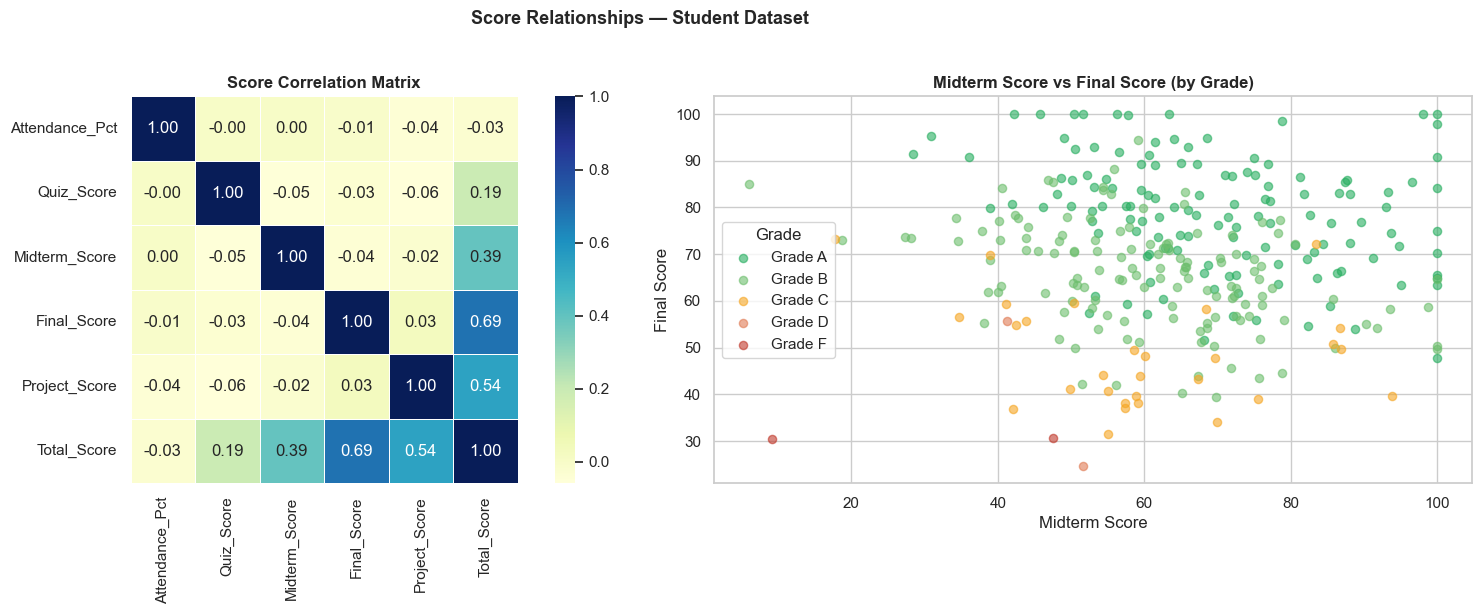

In [56]:
# ═══ Step 5: Score Correlation Heatmap + Pair Scatter ════════════════════════

score_cols = ['Attendance_Pct','Quiz_Score','Midterm_Score',
              'Final_Score','Project_Score','Total_Score']

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Heatmap
corr2 = students_raw[score_cols].corr()
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white', ax=axes[0], square=True)
axes[0].set_title("Score Correlation Matrix", fontweight='bold')

# Scatter: Midterm vs Final Score, colored by Grade
grade_colors = {'A':'#27AE60','B':'#6DBE6D','C':'#F5A623','D':'#E07B54','F':'#C0392B'}
for grade, grp in students_raw.groupby('Grade'):
    axes[1].scatter(grp['Midterm_Score'], grp['Final_Score'],
                    color=grade_colors.get(grade,'gray'),
                    label=f"Grade {grade}", alpha=0.6, s=35)
axes[1].set_title("Midterm Score vs Final Score (by Grade)", fontweight='bold')
axes[1].set_xlabel("Midterm Score"); axes[1].set_ylabel("Final Score")
axes[1].legend(title="Grade")

plt.suptitle("Score Relationships — Student Dataset", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [57]:
# ═══ Step 6: Fully Interactive Student Dashboard (Plotly) ════════════════════

fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Avg Score by Programme","Employment Rate by Programme",
                    "Score Distribution by Programme","Enrolment Trend"),
    specs=[[{"type":"bar"},{"type":"bar"}],
           [{"type":"box"},{"type":"scatter"}]]
)

# Panel 1 — Avg Score
ps = prog_summary.sort_values('Avg_Total', ascending=False)
fig2.add_trace(go.Bar(x=ps['Programme'], y=ps['Avg_Total'],
                      marker_color='steelblue', name='Avg Score'), row=1, col=1)

# Panel 2 — Employment Rate
fig2.add_trace(go.Bar(x=ps['Programme'], y=ps['Employment_Rate']*100,
                      marker_color='coral', name='Employment %'), row=1, col=2)

# Panel 3 — Box plot of Total Score per programme
for prog in students_raw['Programme'].unique():
    fig2.add_trace(go.Box(y=students_raw[students_raw['Programme']==prog]['Total_Score'],
                          name=prog, boxpoints='outliers'), row=2, col=1)

# Panel 4 — Enrolment for top 2 programmes
for prog in programmes_list[:2]:
    fig2.add_trace(go.Scatter(x=monthly_enrol['Month'].astype(str),
                              y=monthly_enrol[prog],
                              mode='lines+markers',
                              name=prog), row=2, col=2)

fig2.update_layout(height=800, title_text="Prodigy Training Hub — Student Analytics Dashboard",
                   showlegend=True)
fig2.show()


---
## Section 8 — Automated Insight Generator

This section programmatically **generates data insights** from the datasets — exactly like an automated reporting tool would. No AI API needed — just smart pandas aggregation and formatting.


In [58]:
# ═══ AUTO INSIGHT GENERATOR — Nigeria Retail Sales ══════════════════════════

def generate_retail_insights(df):
    print("=" * 65)
    print("   NIGERIA RETAIL SALES 2023 — AUTOMATED INSIGHTS REPORT")
    print("=" * 65)
    print()

    total_rev  = df['Revenue_NGN'].sum()
    total_prof = df['Profit_NGN'].sum()
    total_tx   = len(df)
    avg_rating = df['Customer_Rating'].mean()

    print(f"OVERVIEW")
    print(f"  Total Revenue:      ₦{total_rev:>14,.0f}")
    print(f"  Total Profit:       ₦{total_prof:>14,.0f}")
    print(f"  Profit Margin:       {total_prof/total_rev*100:.1f}%")
    print(f"  Total Transactions:  {total_tx:,}")
    print(f"  Avg Customer Rating: {avg_rating:.2f} / 5.00")
    print()

    top_state = df.groupby('State')['Revenue_NGN'].sum().idxmax()
    top_state_rev = df.groupby('State')['Revenue_NGN'].sum().max()
    print(f"TOP PERFORMERS")
    print(f"  Highest Revenue State:    {top_state} (₦{top_state_rev/1e6:.1f}M)")

    top_cat = df.groupby('Category')['Revenue_NGN'].sum().idxmax()
    print(f"  Highest Revenue Category: {top_cat}")

    top_channel = df.groupby('Sales_Channel')['Revenue_NGN'].sum().idxmax()
    top_channel_pct = df.groupby('Sales_Channel')['Revenue_NGN'].sum().max() / total_rev * 100
    print(f"  Best Sales Channel:       {top_channel} ({top_channel_pct:.1f}% of revenue)")
    print()

    month_rev = df.groupby('Month')['Revenue_NGN'].sum()
    best_month = month_rev.idxmax()
    worst_month = month_rev.idxmin()
    print(f"SEASONALITY")
    print(f"  Best Month:  {best_month} (₦{month_rev.max()/1e6:.1f}M)")
    print(f"  Worst Month: {worst_month} (₦{month_rev.min()/1e6:.1f}M)")
    print()

    return_rate = df['Item_Returned'].mean() * 100
    avg_discount = df['Discount_Percent'].mean()
    print(f"RISK FLAGS")
    print(f"  Return Rate:      {return_rate:.1f}% of transactions")
    print(f"  Avg Discount:     {avg_discount:.1f}%")
    print()

    low_rating_cats = df.groupby('Category')['Customer_Rating'].mean().sort_values()
    print(f"  Lowest Avg Rating: {low_rating_cats.index[0]} ({low_rating_cats.iloc[0]:.2f})")
    print()
    print("=" * 65)

generate_retail_insights(df_retail)


   NIGERIA RETAIL SALES 2023 — AUTOMATED INSIGHTS REPORT

OVERVIEW
  Total Revenue:      ₦   305,700,355
  Total Profit:       ₦    80,414,903
  Profit Margin:       26.3%
  Total Transactions:  500
  Avg Customer Rating: 3.32 / 5.00

TOP PERFORMERS
  Highest Revenue State:    Ibadan (₦46.1M)
  Highest Revenue Category: Electronics
  Best Sales Channel:       Online (43.8% of revenue)

SEASONALITY
  Best Month:  May (₦64.6M)
  Worst Month: December (₦11.1M)

RISK FLAGS
  Return Rate:      11.2% of transactions
  Avg Discount:     6.6%

  Lowest Avg Rating: Books & Stationery (3.07)



In [59]:
# ═══ AUTO INSIGHT GENERATOR — Student Performance ════════════════════════════

def generate_student_insights(df, prog_summary):
    print("=" * 65)
    print("   PRODIGY TRAINING HUB — STUDENT PERFORMANCE INSIGHTS")
    print("=" * 65)
    print()

    total_students = len(df)
    completion_rate = (df['Completion_Status'] == 'Completed').mean() * 100
    employment_rate = df['Employed_After'].mean() * 100
    avg_score = df['Total_Score'].mean()
    avg_satisfaction = df['Satisfaction_Rating'].mean()

    print(f"OVERVIEW")
    print(f"  Total Students Enrolled: {total_students}")
    print(f"  Completion Rate:         {completion_rate:.1f}%")
    print(f"  Employment Rate:         {employment_rate:.1f}%")
    print(f"  Average Total Score:     {avg_score:.1f} / 100")
    print(f"  Average Satisfaction:    {avg_satisfaction:.2f} / 5")
    print()

    best_prog_score = prog_summary.sort_values('Avg_Total', ascending=False).iloc[0]
    best_prog_employ = prog_summary.sort_values('Employment_Rate', ascending=False).iloc[0]
    print(f"TOP PROGRAMMES")
    print(f"  Highest Avg Score:      {best_prog_score['Programme']} ({best_prog_score['Avg_Total']:.1f})")
    print(f"  Highest Employment:     {best_prog_employ['Programme']} ({best_prog_employ['Employment_Rate']*100:.1f}%)")
    print()

    grade_dist = df['Grade'].value_counts(normalize=True) * 100
    print(f"GRADE DISTRIBUTION")
    for g in ['A','B','C','D','F']:
        print(f"  Grade {g}: {grade_dist.get(g, 0):.1f}%")
    print()

    dropout_rate = (df['Completion_Status'] == 'Dropped Out').mean() * 100
    low_attend = (df['Attendance_Pct'] < 50).mean() * 100
    print(f"RISK FLAGS")
    print(f"  Dropout Rate:           {dropout_rate:.1f}%")
    print(f"  Students < 50% Attend:  {low_attend:.1f}%")
    print()
    print("=" * 65)

generate_student_insights(students_raw, prog_summary)


   PRODIGY TRAINING HUB — STUDENT PERFORMANCE INSIGHTS

OVERVIEW
  Total Students Enrolled: 300
  Completion Rate:         79.3%
  Employment Rate:         63.3%
  Average Total Score:     68.5 / 100
  Average Satisfaction:    3.90 / 5

TOP PROGRAMMES
  Highest Avg Score:      Power BI (69.4)
  Highest Employment:     Business Analysis (67.0%)

GRADE DISTRIBUTION
  Grade A: 44.3%
  Grade B: 44.7%
  Grade C: 9.7%
  Grade D: 0.7%
  Grade F: 0.7%

RISK FLAGS
  Dropout Rate:           8.7%
  Students < 50% Attend:  2.3%



---
## Section 9 — The Chart Selection Cheat Sheet

Use this as your quick reference whenever you don't know which chart to pick.

---

### By Question Type

| Your Question | Best Chart |
|---------------|-----------|
| How does X change over time? | Line Chart |
| How do categories compare in value? | Bar Chart |
| What proportion does each part contribute? | Pie / Donut Chart |
| What is the distribution of this number? | Histogram, KDE Plot |
| Are there outliers? What is the spread? | Box Plot, Violin Plot |
| Is there a relationship between X and Y? | Scatter Plot |
| How correlated are multiple variables? | Heatmap (correlation) |
| How does value change across two dimensions? | Heatmap (pivot) |
| How does a process convert at each stage? | Funnel Chart |
| How does a total decompose into gains/losses? | Waterfall Chart |
| What is the project timeline? | Gantt Chart |
| How does a subject score across multiple axes? | Radar Chart |
| Show part-to-whole in a hierarchy | Treemap |
| Show 3 variables at once with size | Bubble Chart |

---

### By Data Type

| X-axis Data Type | Y-axis Data Type | Recommended Chart |
|-----------------|-----------------|------------------|
| Time (dates) | Numbers | Line Chart, Area Chart |
| Categories | Numbers | Bar Chart |
| Numbers | Numbers | Scatter Plot |
| One number only | — | Histogram, Box Plot, KDE |
| Two categories | Numbers | Heatmap, Grouped Bar |
| Proportions | — | Pie Chart, Treemap |

---


---
## Section 10 — Saving and Exporting Your Charts

### Saving Matplotlib / Seaborn charts


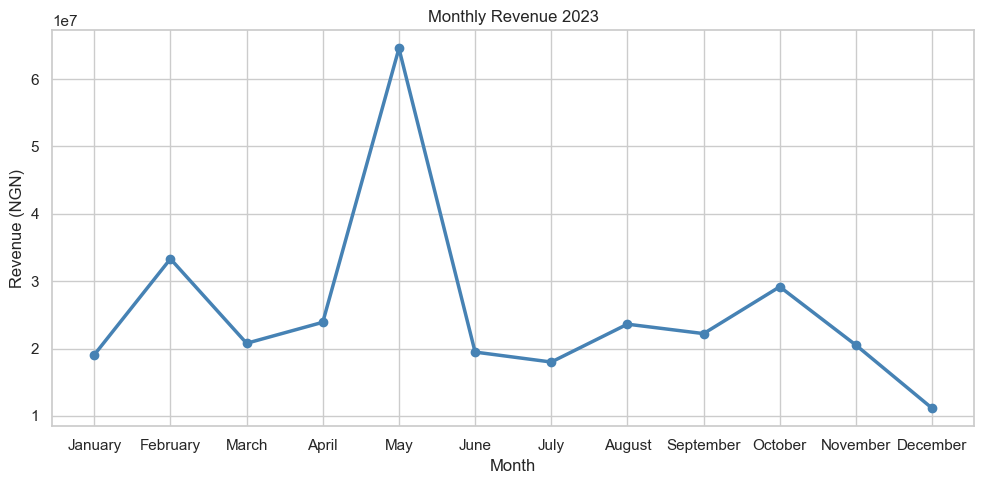

Chart saved in PNG, SVG, and PDF formats.


In [60]:
# ── Save a matplotlib chart to file ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
month_r3 = (df_retail.assign(Month=pd.Categorical(df_retail['Month'], categories=month_order, ordered=True))
                     .groupby('Month')['Revenue_NGN'].sum().sort_index())
ax.plot(month_r3.index, month_r3.values, color='steelblue', marker='o', linewidth=2.5)
ax.set_title("Monthly Revenue 2023"); ax.set_xlabel("Month"); ax.set_ylabel("Revenue (NGN)")
plt.tight_layout()

# Save as PNG (best for reports/slides)
plt.savefig("monthly_revenue.png", dpi=150, bbox_inches='tight')

# Save as SVG (best for web — scales without blurring)
plt.savefig("monthly_revenue.svg", format='svg', bbox_inches='tight')

# Save as PDF (best for printing)
plt.savefig("monthly_revenue.pdf", format='pdf', bbox_inches='tight')

plt.show()
print("Chart saved in PNG, SVG, and PDF formats.")


In [61]:
# ── Save a Plotly chart to HTML (interactive, shareable) ─────────────────────

fig_export = px.bar(state_rev2, x='State', y='Revenue_NGN',
                    title='Revenue by State (Export Demo)')
fig_export.write_html("state_revenue_interactive.html")

print("Interactive chart saved to state_revenue_interactive.html")
print("You can open this file in any browser — no Python needed!")
print("Share it with anyone and they can zoom, hover, and explore the data.")


Interactive chart saved to state_revenue_interactive.html
You can open this file in any browser — no Python needed!
Share it with anyone and they can zoom, hover, and explore the data.


---
## Congratulations — You Have Completed the Python Data Visualization Masterclass!

### What You Covered:

| Section | Topic |
|---------|-------|
| 1 | Environment Setup & Library Installation |
| 2 | Loading Real CSV and Excel Datasets |
| 3 | Matplotlib, Seaborn, and Plotly — Library Overview |
| 4 | ALL Chart Types: Definition, Use Cases, Interpretation, Code |
| 5 | Interactive Charts with Plotly |
| 6 | End-to-End Practical Project — Nigeria Retail Sales (CSV) |
| 7 | End-to-End Practical Project — Student Performance (Excel) |
| 8 | Automated Insight Generation |
| 9 | Chart Selection Cheat Sheet |
| 10 | Exporting and Saving Charts |

---

### Next Steps

1. **Practice daily** — pick any public dataset from Kaggle.com and create 5 different charts
2. **Learn Plotly Dash** — turn your charts into a full web dashboard
3. **Explore GeoPandas** — for mapping and geographic visualizations
4. **Learn Streamlit** — deploy your analytics app online in minutes

---

> *"Data visualization is the last mile of data science — it is how your work reaches the world."*
>
> — Kajola Gbenga Adewale | Prodigy Training Hub

---
